## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

## Read the dataset

In [2]:
df=pd.read_csv(r"C:\Users\NAMRATA\OneDrive\Desktop\python projects\project4b_NHIS\INDUSTRY.csv")

In [3]:
df.shape

(15000, 12)

### There are 15000 rows and 12 columns in the datset.

## Top 5 columns

In [4]:
df.head()

,id,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region
0,1,FinTrust_1,Finance,India,535,539.38,40.42,2010,81191,0.7,13-10-2025,Asia
1,2,TechNova_2,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,01-12-2025,Europe
2,3,RetailHub_3,Retail,Canada,2779,257.11,23.68,1996,27532,2.9,04-05-2025,North America
3,4,BuildWorks_4,Manufacturing,USA,835,309.14,31.31,1993,90815,0.9,01-02-2026,North America
4,5,MediCorp_5,Healthcare,India,4490,988.68,43.65,1996,850,0.5,29-06-2025,Asia


## Botton columns

In [5]:
df.tail()

,id,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region
14995,14996,FinTrust_14996,Finance,USA,2814,369.06,25.59,2011,52295,1.6,25-08-2024,North America
14996,14997,TechNova_14997,Technology,India,3977,758.47,32.68,2019,4118,0.3,30-04-2024,Asia
14997,14998,RetailHub_14998,Retail,Germany,454,859.89,15.36,1999,54468,0.1,05-04-2024,Europe
14998,14999,BuildWorks_14999,Manufacturing,Canada,2787,111.92,41.82,2019,74866,1.9,30-12-2024,North America
14999,15000,MediCorp_15000,Healthcare,USA,1473,879.67,29.31,2003,12998,2.0,14-03-2024,North America


### There are 15,000 records shown at the bottom, which means the dataset has been fully downloaded.


In [6]:
df.drop('id', axis=1, inplace=True)

### id column in the dataset is deleted

## Check For the duplicate data

In [7]:
df.duplicated().sum()

np.int64(0)

### There are no duplicate records in the datset.

## Check for the datatupe and null values.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   company_name            15000 non-null  str    
 1   industry                15000 non-null  str    
 2   country                 15000 non-null  str    
 3   employee_count          15000 non-null  int64  
 4   annual_revenue_million  15000 non-null  float64
 5   profit_margin_percent   15000 non-null  float64
 6   founded_year            15000 non-null  int64  
 7   customer_count          15000 non-null  int64  
 8   market_rating           15000 non-null  float64
 9   created_date            15000 non-null  str    
 10  region                  15000 non-null  str    
dtypes: float64(3), int64(3), str(5)
memory usage: 1.3 MB


### There are no null values in the dataset. However, there is a datatype issue in the **`created_date`** column. It is currently stored as a string (str) and should be converted to a datetime format for better analysis and visualization.


In [9]:
df['created_date']=pd.to_datetime(df['created_date'], format='%d-%m-%Y')

### **`created_date`** converted to datetime from str  

# <mark> Univariate Analysis </mark>

## <mark> 1.Comany Name </mark>

In [10]:
df['company_name']=df['company_name'].str.split('_').str[0]

### The company name contains an unnecessary ID (for example, `FinTrust_14996`). Therefore, the ID should be removed from the company name column.


In [11]:
df['company_name'].nunique()

5

Value count: company_name
FinTrust      3000
TechNova      3000
RetailHub     3000
BuildWorks    3000
MediCorp      3000
Name: count, dtype: int64


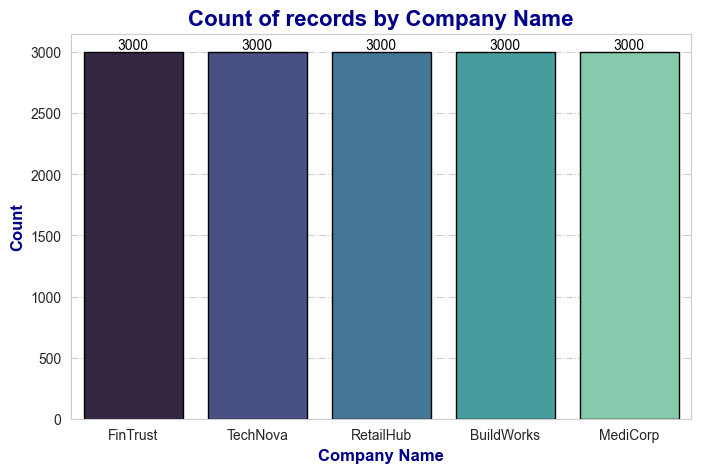

In [12]:
print("Value count:", df['company_name'].value_counts())

sns.set_style('whitegrid')
plt.figure(figsize=(8,5))

company_count=df['company_name'].value_counts()

ax=sns.countplot(x='company_name', data=df, order=company_count.index, palette='mako', hue='company_name',edgecolor='black')
ax.set_title('Count of records by Company Name', fontsize=16, fontweight='bold', color='darkblue')
ax.set_xlabel('Company Name', fontsize=12, fontweight='bold', color='darkblue')
ax.set_ylabel('Count', fontsize=12, fontweight='bold', color='darkblue')
ax.tick_params(rotation=0)

plt.grid(axis='y', linestyle='-.',alpha=1.0)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10, color='black')

plt.show()

### the value count table and count plot shows that all five companies have and equal no of records, with **3000** entries each. This indicates that the company_name column is perfectly balanced, ensuring no company is overpresented or underpresented in the datset. The uniform distribution help in the performing unbaised analysis and visualization.


## <mark> 2.Industry </mark>

In [13]:
df['industry'].nunique()

5

### There are five different industries in the datset.

industry
Finance          3000
Technology       3000
Retail           3000
Manufacturing    3000
Healthcare       3000
Name: count, dtype: int64

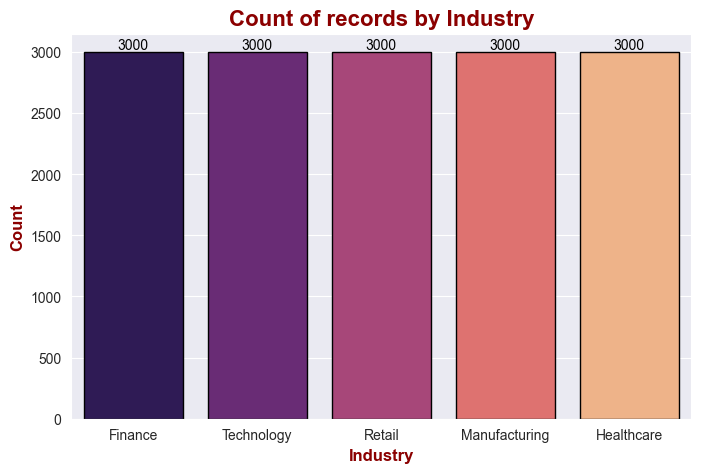

In [14]:
display(df['industry'].value_counts())

sns.set_style('darkgrid')

plt.figure(figsize=(8,5))

industry_value=df['industry'].value_counts()

ax=sns.countplot(x='industry', data=df, hue='industry', order=industry_value.index, palette='magma',edgecolor='black')
ax.set_title('Count of records by Industry', fontsize=16, fontweight='bold', color='darkred')
ax.set_xlabel('Industry', fontsize=12, fontweight='bold', color='darkred')
ax.set_ylabel('Count', fontsize=12, fontweight='bold', color='darkred')
ax.tick_params(rotation=0)      

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10, color='black')

plt.show()

### Same as company_name, the data is evenly distributed across the industries. Each industry contains 3,000 records. The balanced distribution helps maintain consistency in the dataset and reduces bias during analysis and model building.

## <mark> 3. Country </mark>

country
India      3750
Germany    3750
Canada     3750
USA        3750
Name: count, dtype: int64

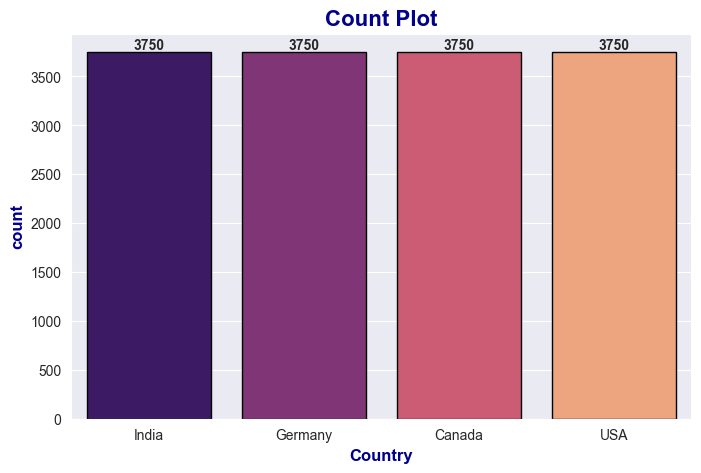

In [15]:
display(df['country'].value_counts())

sns.set_style('darkgrid')

plt.figure(figsize=(8,5))

ax=sns.countplot(x='country',data=df, palette='magma', edgecolor='black', hue='country')
ax.set_xlabel("Country", fontsize=12, color="darkblue", fontweight='bold')
ax.set_ylabel("count", fontsize=12, color="darkblue", fontweight='bold')
ax.set_title ("Count Plot", fontsize=16, fontweight='bold',color='darkblue')

for container in ax.containers:
   ax.bar_label(container, fontweight='bold')

plt.show()



### The **country** column contains data from four countries: India, Germany, Canada and USA. Each country contributes exactly **3750** records, showing that the dataset is uniformaly distributed across all the countries.

## <mark> 4. Region </mark>

region
North America    7500
Asia             3750
Europe           3750
Name: count, dtype: int64

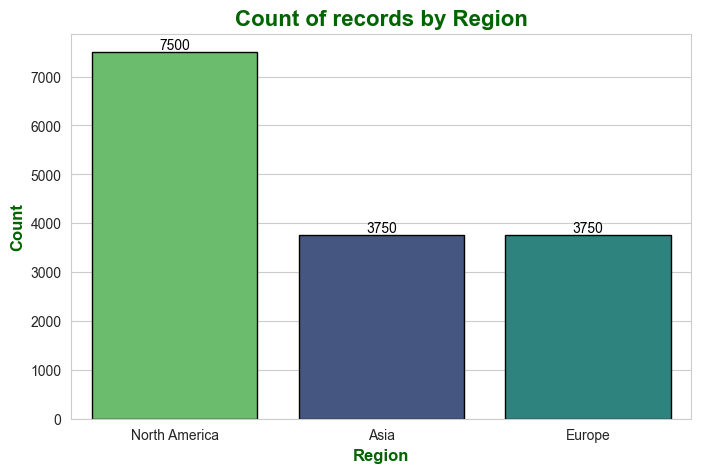

In [16]:
display(df['region'].value_counts())

sns.set_style('whitegrid')

plt.figure(figsize=(8,5))

region_value=df['region'].value_counts()

ax=sns.countplot(x='region', data=df, hue='region', order=region_value.index, palette='viridis',edgecolor='black')
ax.set_title('Count of records by Region', fontsize=16, fontweight='bold',  color='darkgreen')
ax.set_xlabel('Region', fontsize=12, fontweight='bold', color='darkgreen')
ax.set_ylabel('Count', fontsize=12, fontweight='bold', color='darkgreen')
ax.tick_params(rotation=0) 

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10, color='black')    
plt.show()

### The datset contains three records `North America`, `Asia`, and `Europe`. `North America` has 7500 records, while `Asia` and `Europe` each contain 3750 records. This indicates North America has higher representation in the datsetcompared to other regions,which may slighlty influence regional analysis outcomes.

# <mark> Numerical Columns </mark>

## <mark>Box Plots for all numerical column</mark>

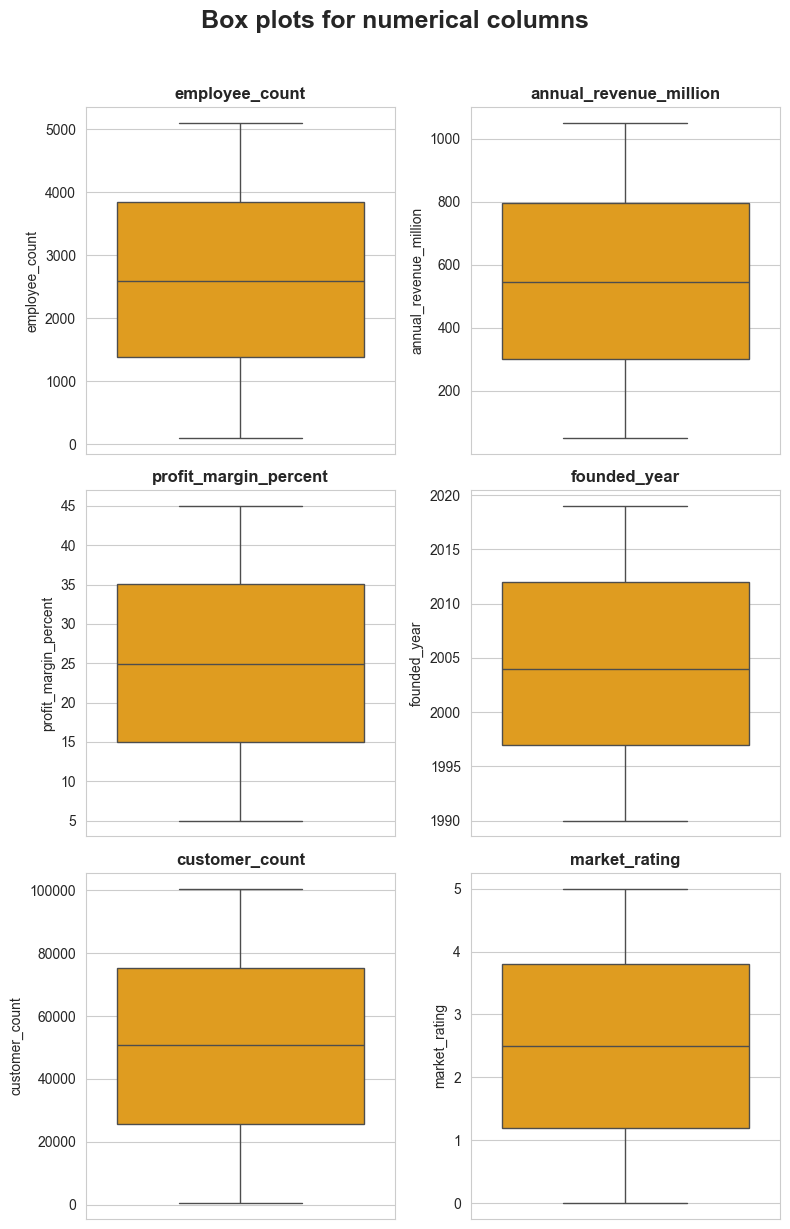

In [17]:
import math

num_cols=df.select_dtypes(include=["int64","float64"]).columns

n_cols=len(num_cols)

cols=2   ## two columns
row=math.ceil(n_cols/cols)

sns.set_style("whitegrid")
plt.figure(figsize=(8,4 * row))

for i, col in enumerate(num_cols,1):
    plt.subplot(row,cols,i)

    sns.boxplot(y=df[col], color='orange')
    plt.title(f'{col}',fontsize=12, fontweight='bold')
    plt.ylabel(col)

plt.suptitle("Box plots for numerical columns", fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()


## Box plot for numerical columns.

### All numerical variables appear well distributed across the ranges. No major outliers are visible in any box plots. Because of the Median line is situated at the centre of the all box, we can say that the distribution is fairly symmetrical. The dataset seem clean and balanced with no exreme outliers.



## <mark>5.Employee Count</mark>

Statistical Analysis

,Value
Count,15000.00
Mean,2606.86
Std Dev,1430.56
Min,100.00
25%,1379.00
Median,2587.00
75%,3839.00
Max,5099.00


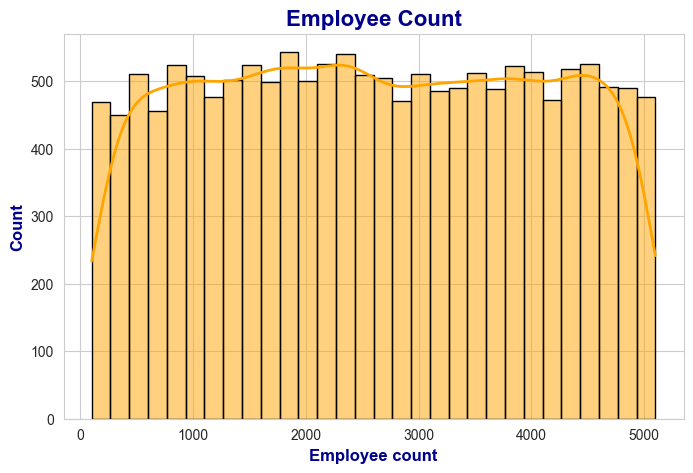

In [18]:
display(Markdown("Statistical Analysis"))
stat=df['employee_count'].describe().round(2).to_frame(name='Value')
stat.index=["Count","Mean","Std Dev","Min","25%","Median","75%","Max"]
display(stat)

sns.set_style('whitegrid')
plt.figure(figsize=(8,5))

# Histogram\
sns.histplot(df['employee_count'], bins=30, kde=True,color='orange', edgecolor='black',line_kws={'color':'red','linewidth':2})
plt.title('Employee Count', fontsize=16,fontweight='bold', color='darkblue')
plt.xlabel('Employee count', fontsize=12, fontweight='bold', color='darkblue')
plt.ylabel('Count', fontsize=12, fontweight='bold', color='darkblue')

plt.show()


### The `employee_count` column contains 15000 records with no missing values, indicating complete data availability. The average employee count is approximately 2607, while the median is 2587, showing the data is fairly symetric with no major skewness. Standard deviation is 1430.56, whichnis relatively high.  Employee count ranges from 100 to 5100 indicates high variability in company sizes.

### The histogram bars are almost equal in height across the range.Employees counts are distributed fairly evenif low to heigh values. No single employee range dominates the dataset.Bars are continueous across the range indicates that there are missing intervals or no unusaul clustering.

### The KDE curve nearly uniform and smooth distribution across employee count, indicating that the data is evenly distributed without any sharp peaks or heavy concentration in specific range. Slight bump indicate mild concentration around 1500-2500 and 4000-4500 range, but different are not extreme

## <mark>6.Annual Revenue Million</mark>

### Statistcal Analysis- Annual Revenue

,Value
Count,15000.0
Mean,550.0
Std Dev,288.0
Min,50.0
25%,300.0
Median,544.0
75%,798.0
Max,1050.0


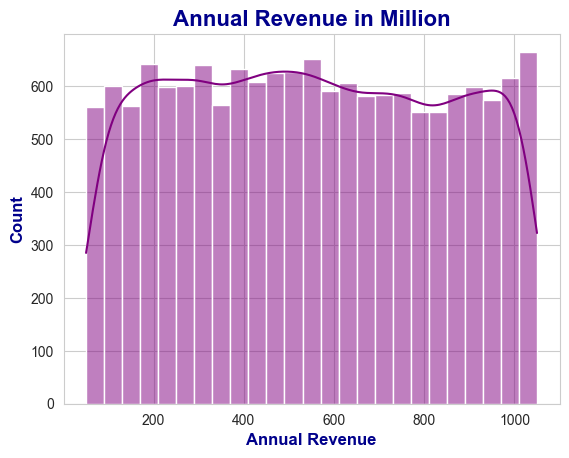

In [19]:
display(Markdown("### Statistcal Analysis- Annual Revenue"))

stat= df["annual_revenue_million"].describe().to_frame(name='Value').round()
stat.index=["Count","Mean","Std Dev","Min","25%","Median","75%","Max"]
display(stat)

sns.set_style("whitegrid")
sns.histplot(x=df["annual_revenue_million"],kde=True,color='purple')
plt.title("Annual Revenue in Million",fontsize=16, color='darkblue', fontweight='bold')
plt.xlabel("Annual Revenue",fontsize=12, color='darkblue', fontweight='bold')
plt.ylabel("Count",fontsize=12, color='darkblue', fontweight='bold')

plt.show()

### `Histogram` bars are almost similar in height across the revenue range indicates the distribution is fairly uniform. Revenue values are spread evenly between 50M to 1050M. Histogram and kde plot do not shows any abnormal spikes.

### `KDE` line remains smooth and relatively flat. Slightly density increases around 400M-600M, but no sharp peak exists

### Since Mean is 550 and Median is 544, confirming low skewness and hence balanced distribution. Standard deviation is relatively high(288), indicates comapny varies in revenue sizes.

## <mark>7.Profit Margin Percentage</mark>

## Statistical Analysis- Profit Margin percentage

,Values
Count,15000.00
Mean,25.01
Std dev,11.53
Min,5.00
25%,15.05
Median,24.91
75%,35.10
Max,45.00


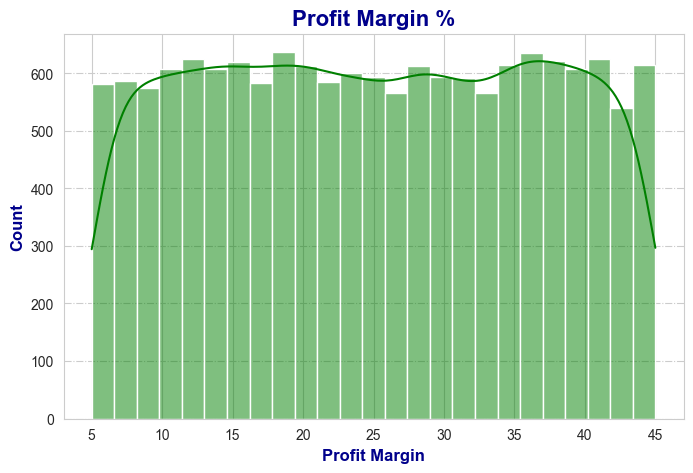

In [20]:
display(Markdown("## Statistical Analysis- Profit Margin percentage"))

stat=df['profit_margin_percent'].describe().round(2).to_frame(name='Values')
stat.index=["Count","Mean","Std dev","Min","25%","Median","75%","Max"]
display(stat)

sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

sns.histplot(x=df["profit_margin_percent"], kde=True, color="green")
plt.title("Profit Margin %",fontsize=16, color='darkblue', fontweight='bold')
plt.xlabel("Profit Margin",fontsize=12, color='darkblue', fontweight='bold')
plt.ylabel("Count",fontsize=12, color='darkblue', fontweight='bold')

plt.grid(axis='y', linestyle="-.")

plt.show()



### `Histogram` bars are relatively equal in height. Profit margin are evenly spread from 5%-45%. 

### `KDE` curve is smooth and relatively flat without sharp spikes. Slight density concemtration around 15-20%,35%-40%, but differnet is small

### Since mean is 25.01 and Median is 24.91, we can say there is no skewness. Standard Deviation is 11.53 indicates that companies shows noticable variation in profitability.

## <mark>8.Founded Year</mark>

In [21]:
df['founded_year'].nunique()

30

## Statistical Analysis

,Value
Count,15000.0
Mean,2004.0
Std dev,9.0
Min,1990.0
25%,1997.0
Median,2004.0
75%,2012.0
Max,2019.0


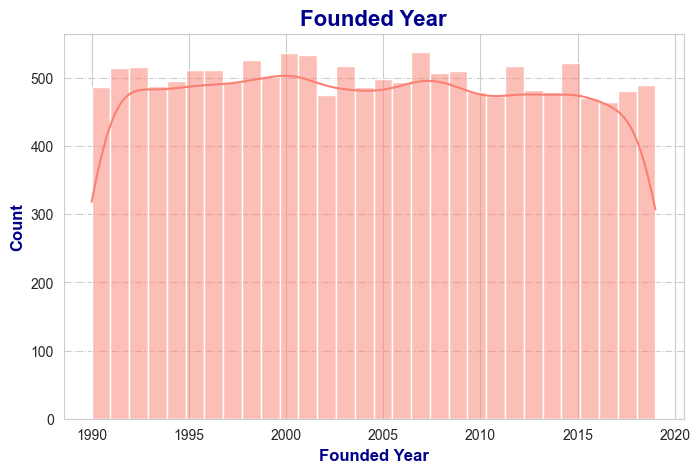

In [22]:
display(Markdown("## Statistical Analysis"))

stat=df["founded_year"].describe().round(0).to_frame(name='Value')
stat.index=["Count","Mean","Std dev","Min","25%","Median","75%","Max"]
display(stat)
plt.figure(figsize=(8,5))

sns.histplot(x=df['founded_year'], bins=30,kde=True, color='salmon')
plt.title("Founded Year",fontsize=16, color='darkblue', fontweight='bold')
plt.xlabel("Founded Year",fontsize=12, color='darkblue', fontweight='bold')
plt.ylabel("Count",fontsize=12, color='darkblue', fontweight='bold')

plt.grid(axis='y', linestyle="-.")

plt.show()

### `Histogram`  bars are relatively equal in height. There are 30 year histry given for companies from 1990 to 2019.

### `KDE` curve is smooth and relatively flat without sharp spikes. Slight density concemtration around 2000-2001, but differnet is small

### Since Mean and median both are equal(2004), we can say evenly distributed founded year. Standard deviation is 9 years means companies are spread between multiple business generation.

## <mark> 9.Customer Count</mark>

## Statistical Analysis

,Value
Count,15000.0
Mean,50449.0
Std dev,28745.0
Min,500.0
25%,25676.0
Median,50726.0
75%,75271.0
Max,100495.0


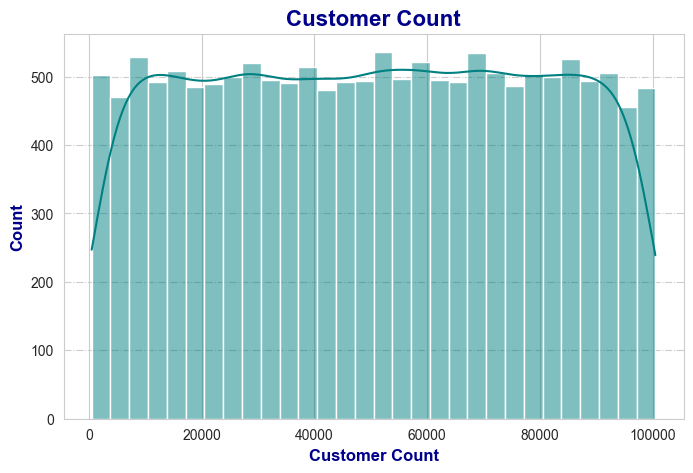

In [23]:
display(Markdown("## Statistical Analysis"))

stat=df["customer_count"].describe().round(0).to_frame(name='Value')
stat.index=["Count","Mean","Std dev","Min","25%","Median","75%","Max"]
display(stat)
plt.figure(figsize=(8,5))

sns.histplot(x=df['customer_count'], bins=30,kde=True, color='teal')
plt.title("Customer Count",fontsize=16, color='darkblue', fontweight='bold')
plt.xlabel("Customer Count",fontsize=12, color='darkblue', fontweight='bold')
plt.ylabel("Count",fontsize=12, color='darkblue', fontweight='bold')

plt.grid(axis='y', linestyle="-.")

plt.show()

### Mean is 50,449 is close to median which is 50,726, indicating distribution is approximately symetrical. Mean and Median are approximately equal that means no strong skewness. Standard deviation is 28,725 which means high variability: Customer counts are widely dispersed.

### `Histogram` shows that the distribution is fairly unifron across the mid range(20ki-80k) with fewwer counts at extreme ends(500 and 100k).No dominant peak observed means customer count are spread evenly.

## <mark>10. Market Rating</mark>

In [24]:
df['market_rating'].nunique()

51

## Statistical Analysis

,Value
Count,15000.0
Mean,3.0
Std dev,1.0
Min,0.0
25%,1.0
Median,2.0
75%,4.0
Max,5.0


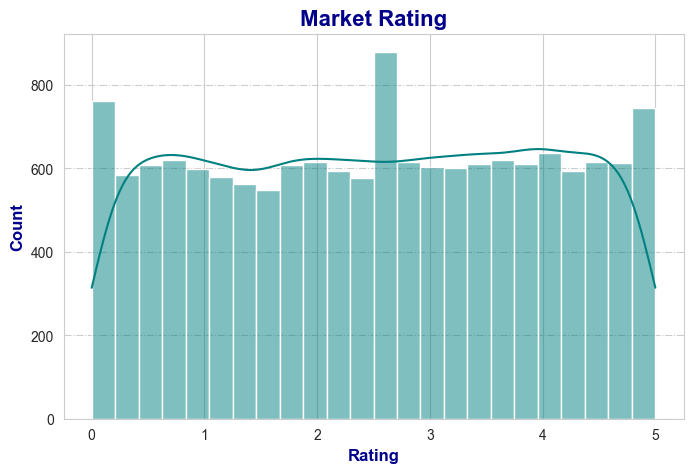

In [25]:
display(Markdown("## Statistical Analysis"))

stat=df["market_rating"].describe().round(0).to_frame(name='Value')
stat.index=["Count","Mean","Std dev","Min","25%","Median","75%","Max"]
display(stat)
plt.figure(figsize=(8,5))

sns.histplot(x=df['market_rating'], color='teal', kde=True)
plt.title("Market Rating",fontsize=16, color='darkblue', fontweight='bold')
plt.xlabel("Rating",fontsize=12, color='darkblue', fontweight='bold')
plt.ylabel("Count",fontsize=12, color='darkblue', fontweight='bold')

plt.grid(axis='y', linestyle="-.")

plt.show()


### Mean is 3.0 shows balanced midpoint,ratings are centered around average satisfaction. Std Dev is 1.0 indicates ratings vary but not excessively (moderate spread). Range (0–5) Full scale utilized → customers express diverse opinions. IQR (1–4)	Middle 50% of ratings → most customers rate between fair and good.

### `Histogram` bars are relatively uniform with the peak at 0,3, and 5, suggesting polarized opinion- some customers are highly dissatisfied, some are neutral and some are highly satisfied.

### `KDE` curve is smooth and slightly flat indicating no sharp concentration around any single rating.

In [26]:
def rating_category(x):
    if x <2:
        return 'Low'
    elif x <4:
        return 'Medium'
    else:
        return 'High'

df['rating_category']=df['market_rating'].apply(rating_category)

## <mark>10.1 Rating Category</mark>

,Value
rating_category,
Medium,6018
Low,5780
High,3202


Rating equal to 0: 161
Rating equal to 5: 162


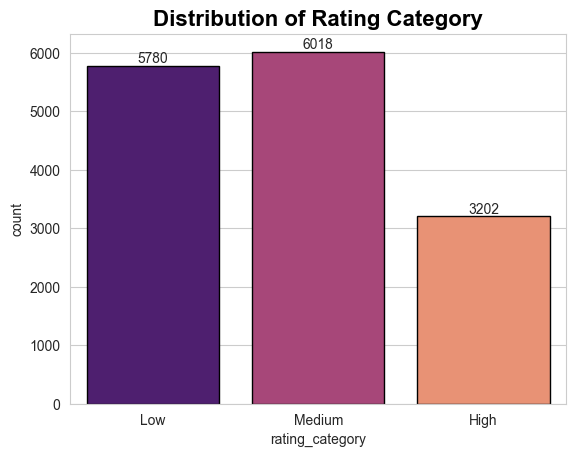

In [27]:

stat= df['rating_category'].value_counts().to_frame(name="Value")
display(stat)

print("Rating equal to 0:",(df["market_rating"]==0).sum())
print("Rating equal to 5:",(df["market_rating"]==5).sum())

sns.set_style('whitegrid')

order=['Low','Medium','High']

ax=sns.countplot(x='rating_category', data=df, order=order, hue='rating_category', palette='magma', edgecolor='black')
ax.set_title("Distribution of Rating Category", fontsize=16, fontweight= 'bold', color='black')

for container in ax.containers:
    ax.bar_label(container)

plt.show()


### `Distribution Insights`: 80% of data contanes Medium and Low rating, the high rating category is significantly smaller. Also, there is near equal count of 0 and 5 ratings indicates balanced extremes, but both are rare- the market sentiment is centered heavily.

## <mark>11.Created Date</mark>

In [28]:
display(Markdown(f"Start Date: {df['created_date'].min()}"))
display(Markdown(f"End Date: {df['created_date'].max()}"))

Start Date: 2024-01-01 00:00:00

End Date: 2026-02-28 00:00:00

In [29]:
df['created_date'].nunique()

790

In [30]:
df=df.drop('created_date',axis=1)

### Since the created_date column has no direct relationship with important business features like revenue, profit margin, customer count or market rating, it is better to remove this column during feature engineering, as it is unlikely to contribute meaningful information to machine learning model.

In [31]:
df.head()

,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,region,rating_category
0,FinTrust,Finance,India,535,539.38,40.42,2010,81191,0.7,Asia,Low
1,TechNova,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,Europe,Medium
2,RetailHub,Retail,Canada,2779,257.11,23.68,1996,27532,2.9,North America,Medium
3,BuildWorks,Manufacturing,USA,835,309.14,31.31,1993,90815,0.9,North America,Low
4,MediCorp,Healthcare,India,4490,988.68,43.65,1996,850,0.5,Asia,Low


# <Mark>Bivariate Analysis</mark>

## <mark>1.Company Name</mark>

In [32]:
pd.crosstab(df['company_name'], df['industry'])

industry,Finance,Healthcare,Manufacturing,Retail,Technology
company_name,,,,,
BuildWorks,0,0,3000,0,0
FinTrust,3000,0,0,0,0
MediCorp,0,3000,0,0,0
RetailHub,0,0,0,3000,0
TechNova,0,0,0,0,3000


In [33]:
df.drop('company_name',axis=1,inplace=True)

### Each company appears with only one indutry throughout the dataset.

### It is better to drop a `company_name` column because it had a one-to-one relationship with `industry` column,making it redundant feature. Keeping both the column would introduced duplicate information to a model. `industry` was retained because it provides broader and more meaningful categorical information for generalization.

## <mark>2.Industry</mark>

### <mark>2.1 Industry vs Country/Region</mark>

country,Canada,Germany,India,USA
industry,,,,
Finance,750,750,750,750
Healthcare,750,750,750,750
Manufacturing,750,750,750,750
Retail,750,750,750,750
Technology,750,750,750,750


region,Asia,Europe,North America
industry,,,
Finance,750,750,1500
Healthcare,750,750,1500
Manufacturing,750,750,1500
Retail,750,750,1500
Technology,750,750,1500


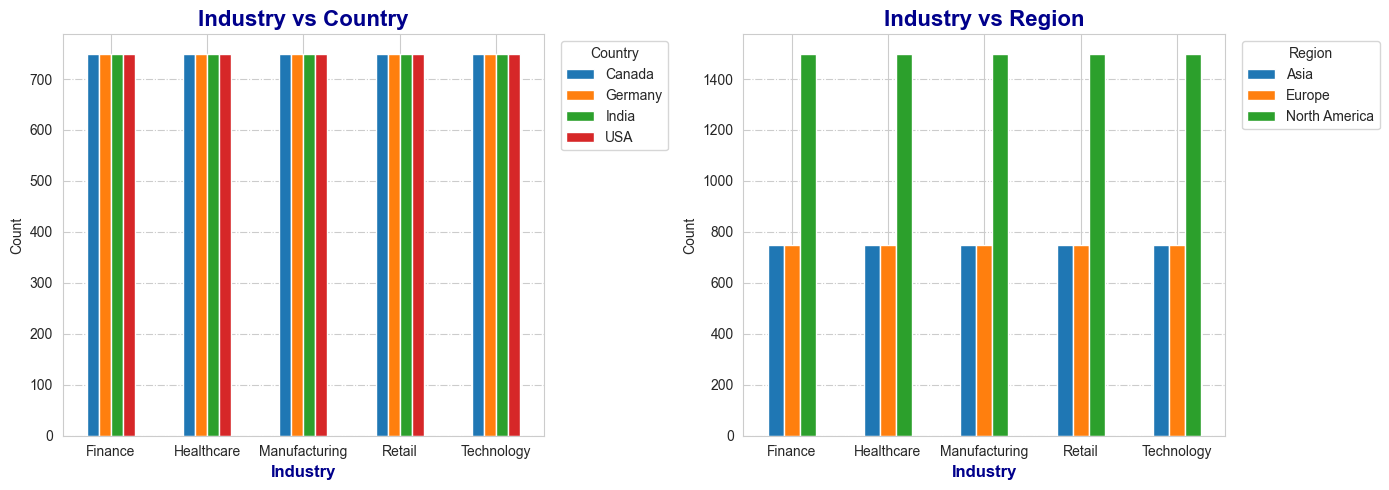

In [34]:
# Create crosstabs
ct1 = pd.crosstab(df['industry'], df['country'])
ct2 = pd.crosstab(df['industry'], df['region'])

display(ct1)
display(ct2)

# Create side-by-side plots
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Industry vs Country
ct1.plot(kind='bar',ax=ax[0])
ax[0].set_title("Industry vs Country",fontsize=16, fontweight='bold',color='darkblue')
ax[0].set_xlabel("Industry",fontsize=12,fontweight='bold',color='darkblue')
ax[0].set_ylabel("Count")
ax[0].tick_params(axis='x', rotation=0)
ax[0].grid(axis='y', linestyle='-.')
ax[0].legend(title='Country',bbox_to_anchor=(1.02, 1))

# Industry vs Region
ct2.plot(kind='bar',ax=ax[1])
ax[1].set_title("Industry vs Region",fontsize=16,fontweight='bold', color='darkblue')
ax[1].set_xlabel("Industry", fontsize=12,fontweight='bold',color='darkblue')
ax[1].set_ylabel("Count")
ax[1].tick_params(axis='x', rotation=0)
ax[1].grid(axis='y', linestyle='-.')
ax[1].legend(title='Region',bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

### `Industry Vs Country`
#### Every industry has exactly the same number of companies in each country. evry company contributes equally to every industry. There is no variation in the distribution. The charts provide no business insights because the bars are identical.

### `Industy Vs Region`
#### North America contains twice as many records as Asia ane Europe.This is because North America contains two Countries: USA and Canada, while there are only one city belongs to both Asia and Europe which is India and Germany respectively.

#### Keeping both creates redundant information without adding predictive value to machine learning model, so it is better to delete one column. Countries may influence revenue or profit. Also, different countries have different market size, regulations,labour cost, economic condition- it is better to keep country column. Because Region is derived from country and region contains less information than-it is good to drop this column.


In [35]:
df.drop('region',axis=1,inplace=True)

### <mark>2.2 Industry vs Rating_category</mark>

rating_category,High,Low,Medium
industry,,,
Finance,628,1170,1202
Healthcare,643,1131,1226
Manufacturing,631,1182,1187
Retail,661,1117,1222
Technology,639,1180,1181


<Figure size 800x500 with 0 Axes>

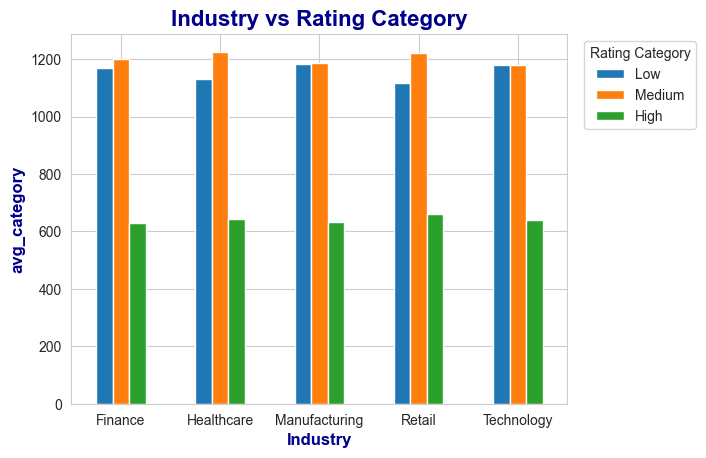

In [36]:
ct=pd.crosstab(df['industry'],df['rating_category'])
display(ct)

order = ["Low", "Medium", "High"]

ct = ct[order]

plt.figure(figsize=(8,5))
ax = ct.plot(kind='bar')
plt.title("Industry vs Rating Category", fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel("Industry",fontsize=12, fontweight='bold',color='darkblue')
plt.ylabel("avg_category",fontsize=12, fontweight='bold',color='darkblue')
plt.xticks(rotation=0)
plt.legend(title='Rating Category', bbox_to_anchor=(1.02,1))


plt.show()

### 'Industry vs Rating Category`

### -`Medium-rated companies` dominate across all indutries. The majority of companies across the industries fall into the  Medium-rating category, indicating a relatively balanced market performance distribution.
### -`Retail` contains the largest number of High_rated companies, suggesting slightly stronger performance compared to other companies. Also `Retail` and `Healthcare` have relatively fewer low reted companies.
### -` Manufacturing and Technology` exibit the highest count of low-rated companies, indicating greater challenges or variability in company performance within these sectors.

### The distribution of rating category is broadly similar across Finance, Healthcare, Manufacturing, Retail and Technology industries. Medium-reated companies constitute the largest segment in every industry, while High-rated companies represents the smallest segment.

### <mark>2.3Industry vs Employee Count</mark>

### Industry vs Employee Count

,Count,Mean,Std dev,Min,25%,Median,75%,Max
industry,,,,,,,,
Finance,3000.0,2621.878333,1424.023980,103.0,1418.75,2602.5,3851.00,5097.0
Healthcare,3000.0,2610.893667,1421.205740,101.0,1376.75,2578.5,3822.00,5098.0
Manufacturing,3000.0,2582.221000,1443.003335,100.0,1304.50,2578.0,3848.00,5099.0
Retail,3000.0,2608.425000,1438.876364,101.0,1385.00,2600.0,3855.00,5099.0
Technology,3000.0,2610.892333,1426.223453,100.0,1433.50,2575.0,3823.75,5093.0


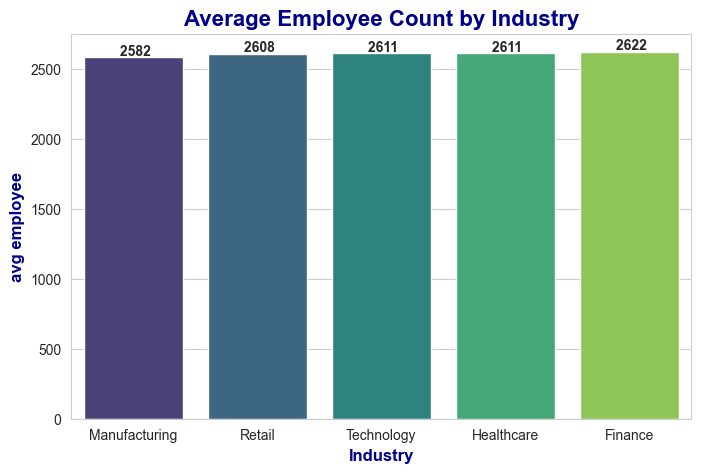

In [37]:
emp_stat=df.groupby('industry')['employee_count'].describe()
emp_stat.columns=["Count","Mean","Std dev","Min","25%","Median","75%","Max"]
display(Markdown("### Industry vs Employee Count"))
display(emp_stat)

avg_emp=df.groupby("industry")["employee_count"].mean().sort_values()

plt.figure(figsize=(8,5))

ax=sns.barplot(x=avg_emp.index, y=avg_emp.values, hue=avg_emp.index, palette='viridis')
plt.title("Average Employee Count by Industry", fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel("Industry", fontsize=12,fontweight='bold', color='darkblue')
plt.ylabel("avg employee", fontsize=12,fontweight='bold', color='darkblue')

for i,v in enumerate(avg_emp.values):
    ax.text(i,v+20, f'{v: .0f}', ha='center', fontweight='bold')

plt.show()

### `Industry vs Employee Count`
### Employee count distributions are highly comparable across Finance, Healthcare, Manufacturing, Retail, and Technology industries. 
### -`Finance` companies exhibit the highest average and median employee counts, indicating marginally larger workforce sizes.
### -`Manufacturing` demonstrates the greatest variability in employee count, suggesting a broader mix of small and large firms. 
### However, differences across industries are minimal, implying that employee count is relatively independent of industry within this dataset and company sizes are uniformly distributed across sectors.



In [38]:
df['employee_size'] = pd.cut(
    df['employee_count'],
    bins=[0,500,1000,2000,3500,6000],
    labels=['Micro','Small','Medium','Large','Enterprise']
)

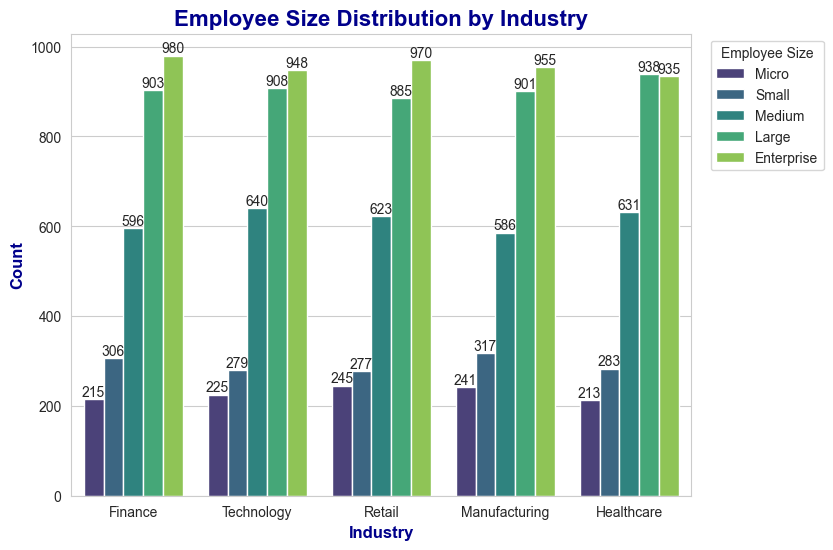

In [39]:
plt.figure(figsize=(8,6))

ax = sns.countplot(x='industry',data=df,hue='employee_size',palette='viridis')

plt.title("Employee Size Distribution by Industry",fontsize=16,fontweight='bold',color='darkblue')
plt.xlabel("Industry",fontsize=12,fontweight='bold',color='darkblue')
plt.ylabel("Count",fontsize=12,fontweight='bold',color='darkblue')
plt.legend(title="Employee Size", bbox_to_anchor=(1.02,1))

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### `Industry vs Employee Size`
### - Large and Enterprise  categories has the highest counts. Each industry has around 900-980 compnies in these categories. Toghether they account for more than 60% of companies in every industry.

### -`Finance` has the largets concentrarion of entrprise-size companies, suggesting a stronger presence of very large organizations compared to other industry.

### -`Healthcare` leads in the large size category, indicating a substaintial number of organizations with sizeable workforce.

### -`Retail and Manufacturing` have relatively more small scale businesses, reflecting a broader mix of company size with these sector.

### -`Manufacturing` shows the strongest representation of Small-sized firm, suggesting greater diversity in workforce size.

### Across all industries Large and Enterprise organization form a majority of companies, while Macro and Small firm represent a smaller share. Overall, the cemployee size distribution remains remarkably consistance across industries, suggesting balanced representation of company sized regardless of sector.

## <mark>2.4 Industry vs annual_revenue_million</mark>

### Industry vs Annual Revenue (M)

,Count,Mean,Std dev,Min,25%,Median,75%,Max
industry,,,,,,,,
Finance,3000.0,552.82,288.65,51.93,303.97,549.49,807.82,1049.96
Healthcare,3000.0,543.46,286.32,50.33,298.40,532.97,782.41,1049.71
Manufacturing,3000.0,545.58,290.15,50.16,295.37,536.48,797.63,1049.96
Retail,3000.0,556.61,289.36,51.03,302.43,562.08,802.47,1049.87
Technology,3000.0,550.20,286.71,51.05,301.63,541.95,791.64,1049.91


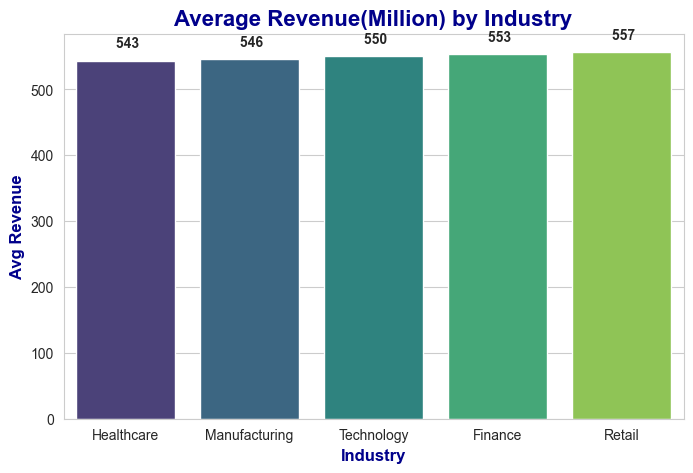

In [40]:
rev_stat=df.groupby('industry')['annual_revenue_million'].describe()
rev_stat.columns=["Count","Mean","Std dev","Min","25%","Median","75%","Max"]
display(Markdown("### Industry vs Annual Revenue (M)"))
display(rev_stat.round(2))

avg_rev=df.groupby("industry")["annual_revenue_million"].mean().sort_values()

plt.figure(figsize=(8,5))

ax=sns.barplot(x=avg_rev.index, y=avg_rev.values, hue=avg_rev.index, palette='viridis')
plt.title("Average Revenue(Million) by Industry", fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel("Industry", fontsize=12,fontweight='bold', color='darkblue')
plt.ylabel("Avg Revenue", fontsize=12,fontweight='bold', color='darkblue')

for i,v in enumerate(avg_rev.values):
    ax.text(i,v+20, f'{v: .0f}', ha='center', fontweight='bold')

plt.show()

### `Industry vs Annual Revenue`
### Revenue levels are fairly uniform across the indutries, indicating that the industry alone is not a strong differentiator of revenue in the dataset.

### -`Retail` companies generated the highest average revenue, suggesting slightly stronger revenue performance compared to other industries. Retrail consistently outperform other industries in both avg and median revenue.While 'Healthcare` records the lowest revenue though the difference is relatively small.

### -Each industry contains both low and high revenue firms, indicating balanced distribution of company sizes and performance level.

### Standard Dev and revenue ranges across the sectors indicate that the company revenue is broadly distributed regardless of industry, suggesting that the comapny revenue has only a limited influence on revenue performance in this dataset.



In [41]:
df['revenue_category'] = pd.qcut(
    df['annual_revenue_million'],
    q=4,
    labels=['Low', 'Mid-Low', 'Mid-High', 'High'])
rev_cat=pd.crosstab(df["industry"],df["revenue_category"], normalize='index')*100
display(Markdown("### Inustry vs Revenue Category"))
display(rev_cat.round(2))

### Inustry vs Revenue Category

revenue_category,Low,Mid-Low,Mid-High,High
industry,,,,
Finance,24.50,25.03,24.43,26.03
Healthcare,25.17,26.10,25.03,23.70
Manufacturing,25.70,24.80,24.47,25.03
Retail,24.73,23.63,26.13,25.50
Technology,24.90,25.43,25.00,24.67


### `Industry vs Revenue` :Revenue categories are distributed very evenly across industries, suggesting that indutry type has little influence on revenue classification in this dataset.

### Most companies are fall into Low, Medium and High categories, creating a balanced revenue structure across the dataset.

### `Retail` contains largest share of very high revenue companies, suggesting slightly stronger revenue performance at the upper end. Retail has the smallest share of very low-revenue companies, reinforcing the observation that it tends to perform slightly better in terms of revenue generation.

### `Healthcare` shows the highest concentration of low-revenue firms, although the difference from other industries is relatively small.

### Revenue category distributions are highly consistence across all indistries.


### <mark>2.5 Industry vs Profit Margin %</mark>

### Industry vs Profit Margin(%)

,Count,Mean,Std dev,Min,25%,Median,75%,Max
industry,,,,,,,,
Finance,3000.0,25.30,11.58,5.01,15.65,25.52,35.62,44.99
Healthcare,3000.0,24.88,11.59,5.01,14.65,24.56,35.23,45.00
Manufacturing,3000.0,24.76,11.36,5.00,15.13,24.52,34.53,45.00
Retail,3000.0,25.09,11.70,5.04,14.65,25.54,35.35,44.99
Technology,3000.0,25.03,11.40,5.01,15.14,24.75,35.00,44.99


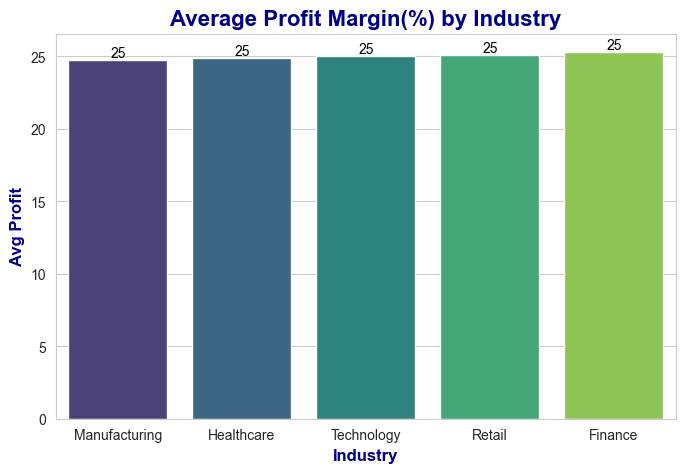

In [42]:
profit_stat=df.groupby('industry')['profit_margin_percent'].describe()
profit_stat.columns=["Count","Mean","Std dev","Min","25%","Median","75%","Max"]
display(Markdown("### Industry vs Profit Margin(%)"))
display(profit_stat.round(2))

avg_profit=df.groupby("industry")["profit_margin_percent"].mean().sort_values()

plt.figure(figsize=(8,5))

ax=sns.barplot(x=avg_profit.index, y=avg_profit.values, hue=avg_profit.index, palette='viridis')
plt.title("Average Profit Margin(%) by Industry", fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel("Industry", fontsize=12,fontweight='bold', color='darkblue')
plt.ylabel("Avg Profit", fontsize=12,fontweight='bold', color='darkblue')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=10, color='black')

plt.show()

### `Industry vs Profit Margin`

### Profit margin percentages are highly consistent across all industries, with average values ranging from 24.76% to 25.30%. The small differences in means, medians, and standard deviations indicate that profitability is distributed similarly across sectors. This suggests that industry type has limited influence on profit margin within the dataset.

In [43]:
df['profit_category'] = pd.cut(
    df['profit_margin_percent'],
    bins=[0, 10, 20, 30, 40, 50],
    labels=[
        'Very Low Profit',
        'Low Profit',
        'Medium Profit',
        'High Profit',
        'Very High Profit'
    ])

profit_cat = pd.crosstab(
    df["industry"],
    df["profit_category"],
    normalize='index'
) * 100

display(Markdown("### Industry vs Profit Category"))

display(profit_cat.round(2))

### Industry vs Profit Category

profit_category,Very Low Profit,Low Profit,Medium Profit,High Profit,Very High Profit
industry,,,,,
Finance,12.37,24.37,24.87,25.33,13.07
Healthcare,12.40,25.73,24.53,25.30,12.03
Manufacturing,12.37,25.37,26.77,24.20,11.30
Retail,12.97,25.10,22.53,26.93,12.47
Technology,11.20,26.13,25.77,24.67,12.23


### `Industry Vs Profit category`

### Profitability distributions are broadly similar across industries, with most companies concentrated in the Low, Medium, and High profit categories. 

### `Retail` exhibits the strongest profitability profile, recording the highest proportion of High-Profit companies, while `Finance` leads in the Very High-Profit category. 
### `Manufacturing` is characterized by a larger share of Medium-Profit firms, and `Technology` has the lowest proportion of Very Low-Profit companies. 

### Overall, differences between industries are relatively modest, indicating that profitability is distributed fairly evenly across sectors.

### <mark>2.6 Industry vs Founded year</mark>

### Industry vs Founded Year

,Count,Mean,Std dev,Min,25%,Median,75%,Max
industry,,,,,,,,
Finance,3000.0,2004.25,8.65,1990.0,1997.0,2005.0,2012.0,2019.0
Healthcare,3000.0,2004.34,8.56,1990.0,1997.0,2004.0,2012.0,2019.0
Manufacturing,3000.0,2004.30,8.61,1990.0,1997.0,2004.0,2012.0,2019.0
Retail,3000.0,2004.46,8.64,1990.0,1997.0,2004.0,2012.0,2019.0
Technology,3000.0,2004.52,8.57,1990.0,1997.0,2004.0,2012.0,2019.0


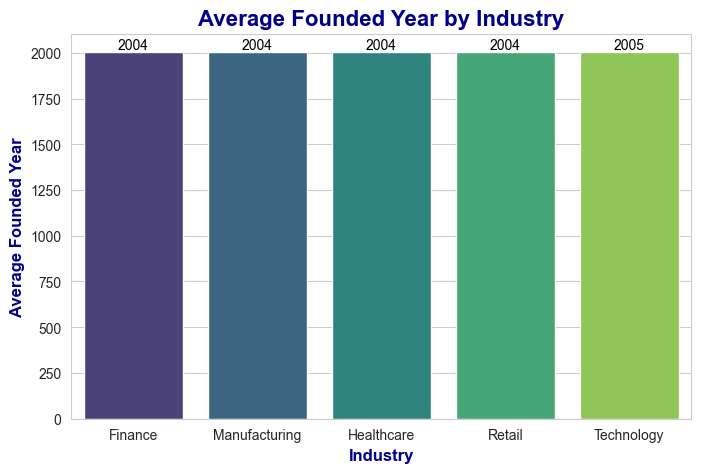

In [44]:
founded_stat = df.groupby('industry')['founded_year'].describe()

founded_stat.columns = ["Count","Mean","Std dev","Min","25%","Median","75%","Max"]

display(Markdown("### Industry vs Founded Year"))
display(founded_stat.round(2))

avg_founded = df.groupby("industry")["founded_year"].mean().sort_values()

plt.figure(figsize=(8,5))

ax = sns.barplot(x=avg_founded.index,y=avg_founded.values,hue=avg_founded.index,palette='viridis',legend=False)

plt.title("Average Founded Year by Industry",fontsize=16,fontweight='bold',color='darkblue')

plt.xlabel("Industry",fontsize=12,fontweight='bold',color='darkblue')

plt.ylabel("Average Founded Year",fontsize=12,fontweight='bold',color='darkblue')

for container in ax.containers:
    ax.bar_label(container,fmt='%.0f',fontsize=10,color='black')

plt.show()


### The founding year distribution is highly consistent across Finance, Healthcare, Manufacturing, Retail, and Technology industries. 

### Average founding years are clustered around 2004, with median values of 2004–2005 across all sectors. Similar standard deviations, quartiles, and ranges indicate that industries contain comparable proportions of older and newer companies. Overall, industry type does not appear to significantly influence company age within the dataset.

founded_period,1990s,2000s,2010s
industry,,,
Finance,1047,993,960
Healthcare,1012,1028,960
Manufacturing,1024,1001,975
Retail,975,1031,994
Technology,986,1044,970


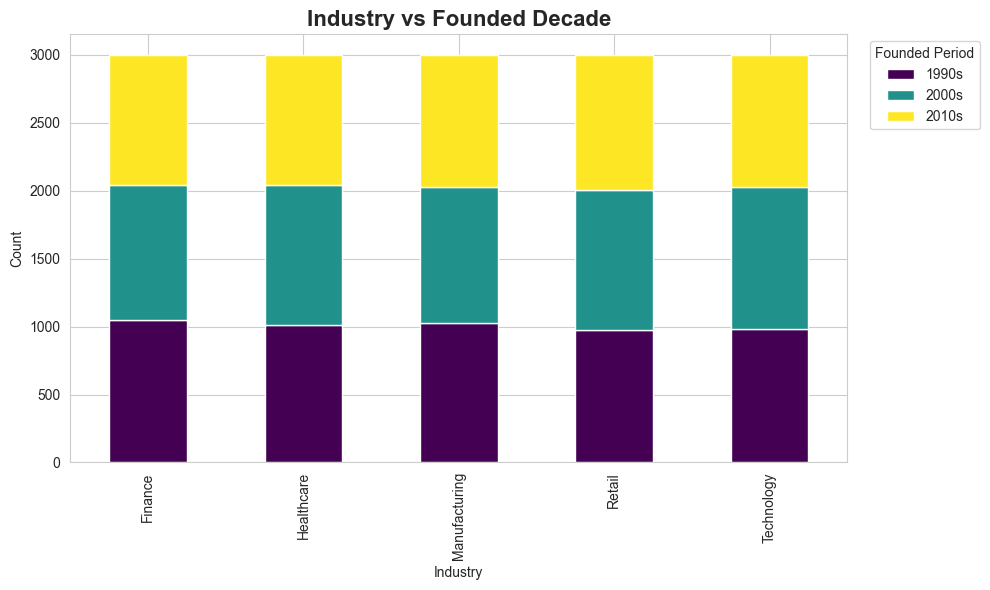

In [45]:
df['founded_period'] = pd.cut(
    df['founded_year'],
    bins=[1989, 1999, 2009, 2019],
    labels=['1990s','2000s','2010s'])

founded_ct = pd.crosstab(df['industry'],df['founded_period'])
display(founded_ct)

founded_ct.plot(kind='bar',stacked=True,figsize=(10,6),colormap='viridis')

plt.title('Industry vs Founded Decade', fontsize=16,fontweight='bold')

plt.xlabel('Industry')
plt.ylabel('Count')

plt.legend(title='Founded Period',bbox_to_anchor=(1.02,1))

plt.tight_layout()
plt.show()

### The distribution of companies across founding decades is highly balanced across all industries. 
### Approximately one-third of companies in each sector were founded during the 1990s, 2000s, and 2010s. 
### `Finance` contains a slightly larger proportion of older firms founded in the 1990s, while `Retail` has the highest representation of companies established in the 2010s. `Technology` shows a marginal concentration in the 2000s. However, the differences between industries are relatively small, suggesting that company age is broadly independent of industry within the dataset.

### <mark>2.7 Industry vs Customer Count</mark>

### Industry vs Customer Count

,Count,Mean,Std dev,Min,25%,Median,75%,Max
industry,,,,,,,,
Finance,3000.0,50665.92,28930.76,551.0,25494.50,51032.0,76181.50,100433.0
Healthcare,3000.0,51025.38,28484.31,508.0,26540.50,51377.0,75345.50,100424.0
Manufacturing,3000.0,50220.06,28792.06,555.0,25727.50,50644.0,74802.50,100495.0
Retail,3000.0,49979.26,28639.67,564.0,25479.25,49724.5,74548.00,100486.0
Technology,3000.0,50355.64,28881.72,500.0,25155.00,50715.5,75327.75,100492.0


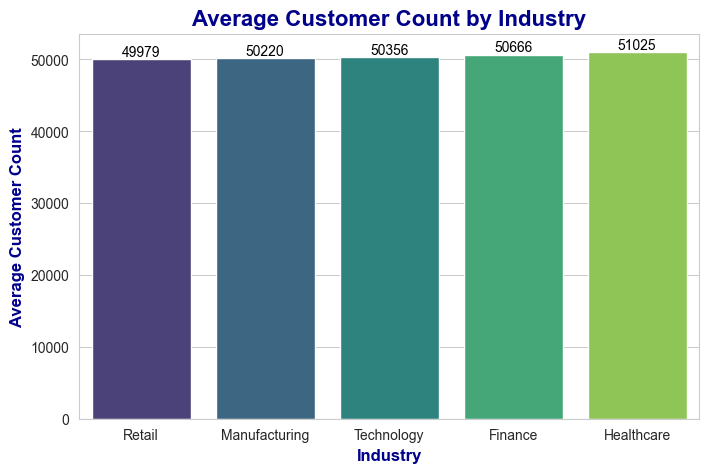

In [46]:
customer_stat = df.groupby('industry')['customer_count'].describe()

customer_stat.columns = ["Count","Mean","Std dev","Min","25%", "Median","75%","Max"]

display(Markdown("### Industry vs Customer Count"))
display(customer_stat.round(2))

avg_customer = df.groupby("industry")["customer_count"].mean().sort_values()

plt.figure(figsize=(8,5))

ax = sns.barplot(x=avg_customer.index,y=avg_customer.values,hue=avg_customer.index,palette='viridis',legend=False)

plt.title("Average Customer Count by Industry",fontsize=16,fontweight='bold',color='darkblue')
plt.xlabel("Industry",fontsize=12,fontweight='bold',color='darkblue')
plt.ylabel("Average Customer Count",fontsize=12,fontweight='bold',color='darkblue')

for container in ax.containers:
    ax.bar_label(container,fmt='%.0f',fontsize=10,color='black')

plt.show()

### `Industry vs Avg Customer Count`
### Customer bases are distributed very evenly across industries, suggesting that industry has limited influence on customer count in this dataset.

### `Healthcare` organizations have the largest customer base on average, indicating slightly stronger customer reach compared to other sectors. 
### `Retail` companies serve slightly fewer customers on average, although the difference from other industries is minimal.

### Median customer counts closely match the means, indicating balanced distributions without significant skewness.
### Customer count variability is almost identical across industries, suggesting a similar mix of small-, medium-, and large-customer-base companies.

### Customer counts are distributed very similarly across Finance, Healthcare, Manufacturing, Retail, and Technology industries.Overall, industry type appears to have only a limited influence on customer count within this dataset.


In [47]:
df['customer_category'] = pd.cut(
    df['customer_count'],
    bins=[0, 20000, 40000, 60000, 80000, 120000],
    labels=[
        'Very Low Customers',
        'Low Customers',
        'Medium Customers',
        'High Customers',
        'Very High Customers'])


customer_cat = pd.crosstab(df['industry'],df['customer_category'],normalize='index') * 100

display(Markdown("### Industry vs Customer Category"))
display(customer_cat.round(2))


### Industry vs Customer Category

customer_category,Very Low Customers,Low Customers,Medium Customers,High Customers,Very High Customers
industry,,,,,
Finance,19.30,20.83,19.37,19.30,21.20
Healthcare,18.33,19.87,20.73,20.90,20.17
Manufacturing,19.80,19.60,20.23,20.30,20.07
Retail,19.90,20.30,20.53,19.93,19.33
Technology,19.83,19.53,20.13,20.37,20.13


### `Industry vs Customer category`
### Each industry contains a balanced mix of companies with low, medium, and high customer counts, indicating no strong relationship between industry type and customer category.

### `Finance` has the largest proportion of companies in the highest customer-count category, suggesting a slightly stronger concentration of firms with large customer bases.
### `Healthcare` contains the fewest companies in the lowest customer-count segment, indicating relatively stronger customer reach.
### `Retail` has the smallest share of companies with very large customer bases, although the difference from other industries is modest.

### <mark>2.7 Industry vs Market rating</mark>

### Industry vs Market Rating

,Count,Mean,Std dev,Min,25%,Median,75%,Max
industry,,,,,,,,
Finance,3000.0,2.51,1.45,0.0,1.2,2.5,3.80,5.0
Healthcare,3000.0,2.52,1.44,0.0,1.3,2.5,3.70,5.0
Manufacturing,3000.0,2.49,1.45,0.0,1.2,2.5,3.72,5.0
Retail,3000.0,2.55,1.45,0.0,1.3,2.6,3.80,5.0
Technology,3000.0,2.50,1.45,0.0,1.2,2.5,3.80,5.0


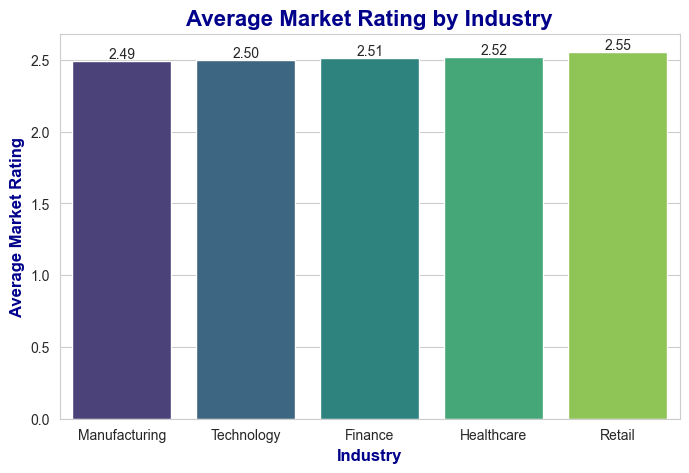

In [48]:
rating_stat = df.groupby('industry')['market_rating'].describe()

rating_stat.columns = ["Count","Mean","Std dev","Min","25%","Median","75%","Max"]

display(Markdown("### Industry vs Market Rating"))
display(rating_stat.round(2))

avg_rating = df.groupby("industry")["market_rating"].mean().sort_values()

plt.figure(figsize=(8,5))

ax = sns.barplot(x=avg_rating.index,y=avg_rating.values,hue=avg_rating.index,palette='viridis',legend=False)

plt.title("Average Market Rating by Industry",fontsize=16,fontweight='bold',color='darkblue')

plt.xlabel("Industry",fontsize=12,fontweight='bold',color='darkblue')
plt.ylabel("Average Market Rating",fontsize=12,fontweight='bold',color='darkblue')

for container in ax.containers:
    ax.bar_label(container,fmt='%.2f',fontsize=10)

plt.show()

### `Industry vs Rating`

### Market ratings are distributed very uniformly across Finance, Healthcare, Manufacturing, Retail, and Technology industries. 

### Average ratings range from 2.49 to 2.55, with Retail recording the highest mean rating and Manufacturing the lowest. Similar medians, quartiles, standard deviations, and rating ranges indicate that industry type has minimal influence on market ratings within this dataset. 

### Overall, market perception appears largely independent of industry.

## <mark>3. Country</mark>

### <mark> 3.1 Country vs Employee count</mark>

employee_size,Micro,Small,Medium,Large,Enterprise
country,,,,,
Canada,309,406,759,1107,1169
Germany,273,340,794,1120,1223
India,287,362,772,1148,1181
USA,270,354,751,1160,1215


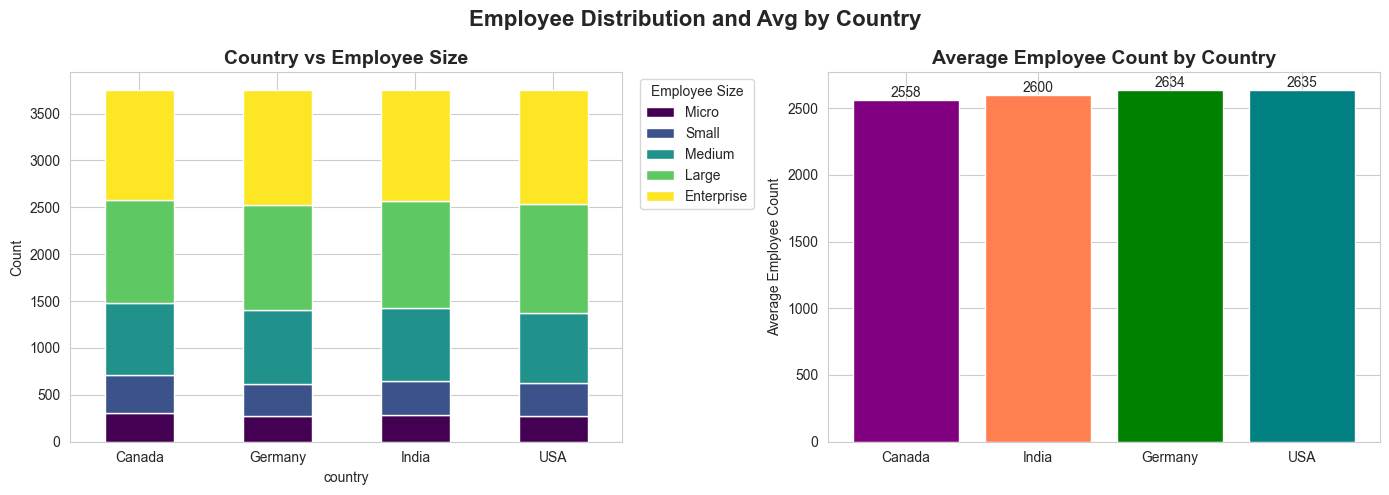

In [49]:
ct = pd.crosstab(df["country"], df["employee_size"])
display(ct)

avg_emp = df.groupby('country')['employee_count'].mean().sort_values()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Crosstab
ct.plot(kind='bar',stacked=True,ax=ax[0],colormap='viridis')

ax[0].set_title('Country vs Employee Size',fontsize=14,fontweight='bold')
ax[0].set_ylabel('Count')
ax[0].tick_params(rotation=0)
ax[0].legend(title='Employee Size',bbox_to_anchor=(1.02,1))


# Average employee count
colour=['purple','coral','green','teal']
bars = ax[1].bar(avg_emp.index,avg_emp.values,color=colour)

ax[1].set_title('Average Employee Count by Country',fontsize=14,fontweight='bold')
ax[1].set_ylabel('Average Employee Count')
ax[1].tick_params(axis='x', rotation=0)

for bar in bars:
    height = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2,height,f'{height:.0f}',ha='center',va='bottom')

fig.suptitle('Employee Distribution and Avg by Country', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

### `Employee Distribution and Avg by Country`
### Across all the countries `Large` and `Enterprise` firms contributes largest shares of companies, suggesting that the dataset is heavily skewed towards larger organization and strong representation of mature business.`Germany` shows slightly greater concentration of very large organization.
### Smaller(`Micro and Small`) busimesses are underpresented compared to larger firms. 'Canada` appears to have relatively stronger presence of smaller firms compared to other countries.

### Company size composition does not vary significantly by country. Each country has a balanced mix of Small, Medium and Large firms. Companies in `USA` and `Germany` are marginally larger on average but the difference is negligible. Employee count appears to driven more by company-specific factors than country.


### <mark>3.2 Country vs Annual Revenue(Million)</mark>

revenue_category,Low,Mid-Low,Mid-High,High
country,,,,
Canada,941,927,950,932
Germany,948,958,925,919
India,942,932,933,943
USA,919,933,944,954


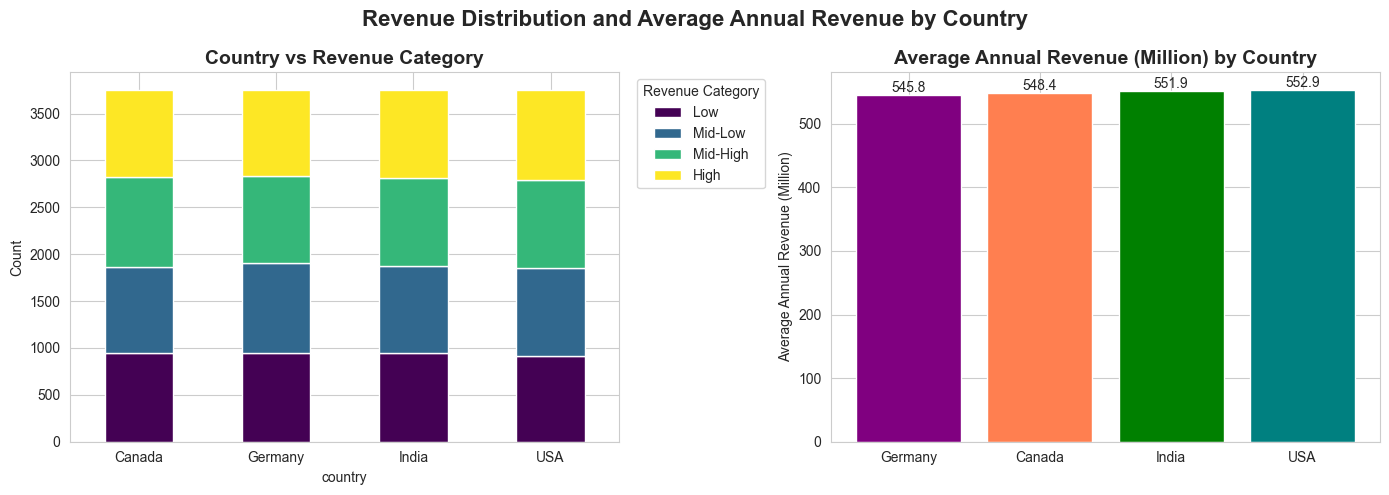

In [50]:
ct = pd.crosstab(df["country"], df["revenue_category"])
display(ct)

avg_rev = df.groupby('country')['annual_revenue_million'].mean().sort_values()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

#  stack
ct.plot(kind='bar', stacked=True, ax=ax[0], colormap='viridis')
ax[0].set_title('Country vs Revenue Category', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Count')
ax[0].tick_params(rotation=0)
ax[0].legend(title='Revenue Category', bbox_to_anchor=(1.02, 1))

# bar
colour = ['purple', 'coral', 'green', 'teal']
bars = ax[1].bar(avg_rev.index, avg_rev.values, color=colour)
ax[1].set_title('Average Annual Revenue (Million) by Country', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Average Annual Revenue (Million)')
ax[1].tick_params(axis='x', rotation=0)

# Add labels above bars
for bar in bars:
    height = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2, height,f'{height:.1f}', ha='center', va='bottom')


fig.suptitle('Revenue Distribution and Average Annual Revenue by Country',fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


### 'Revenue Distribution and Avg Revenue by Country`
### All four countries show remarkably consistent revenue distributions, indicating comparable business maturity levels. The `Low` and `Medium` categories form the bulk (~50–55%) of firms in each country.

### `India` edges ahead in the Very High category, hinting at a few standout enterprises driving top‑end growth. `USA` maintains a strong High segment, reflecting stable mid‑to‑large revenue firms.

### The dataset reveal structural similarity across countries- no extreme skew towards low or high revenue tiers.

### <mark>3.3 Country Vs Profit Margin(%)</mark>

profit_category,Very Low Profit,Low Profit,Medium Profit,High Profit,Very High Profit
country,,,,,
Canada,460,947,934,947,462
Germany,493,918,911,983,445
India,437,987,902,978,446
USA,449,949,987,885,480


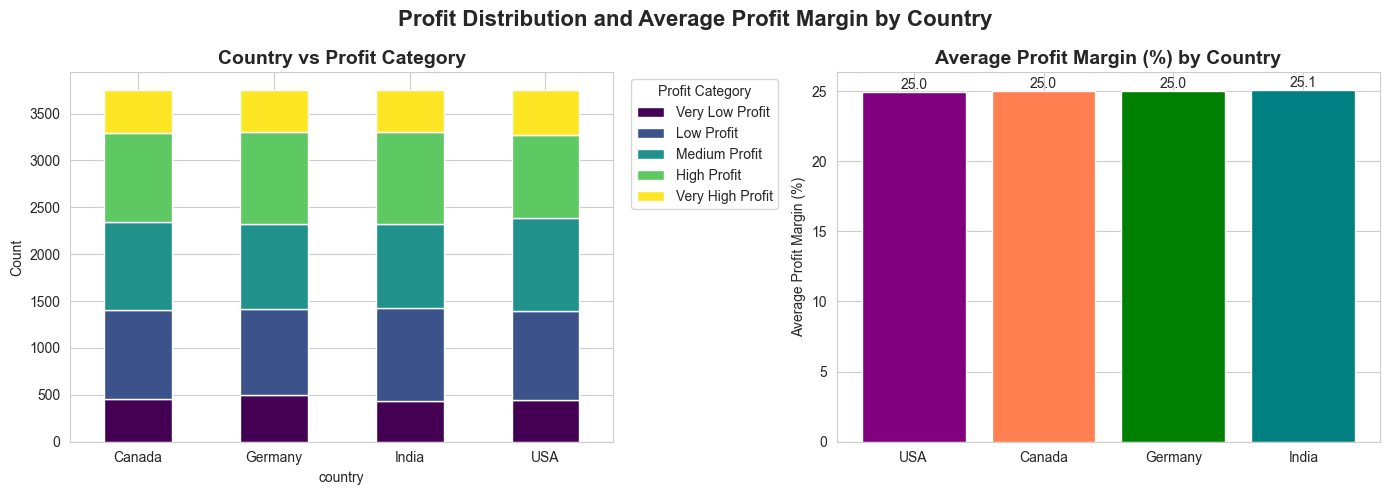

In [51]:
ct = pd.crosstab(df["country"], df["profit_category"])
display(ct)

avg_profit = df.groupby('country')['profit_margin_percent'].mean().sort_values()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# tacked 
ct.plot(kind='bar', stacked=True, ax=ax[0], colormap='viridis')
ax[0].set_title('Country vs Profit Category', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Count')
ax[0].tick_params(rotation=0)
ax[0].legend(title='Profit Category', bbox_to_anchor=(1.02, 1))

#  bar 
colour = ['purple', 'coral', 'green', 'teal']
bars = ax[1].bar(avg_profit.index, avg_profit.values, color=colour)
ax[1].set_title('Average Profit Margin (%) by Country', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Average Profit Margin (%)')
ax[1].tick_params(axis='x', rotation=0)


for bar in bars:
    height = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2, height,f'{height:.1f}', ha='center', va='bottom')

# Global title
fig.suptitle('Profit Distribution and Average Profit Margin by Country',fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


### `Profit Distribution and Avg Profit Margin by Country`

### All four countries show rematkably similar profit distributions. The low-High profit tier dominate, forming the backbone of profitability.`Germany` and `India` lean towards high profit, while `USA` shows a stronger Medium profit presence.

### Each bar hovers around 25%, showing no significant variation in average profit margin across the countries. `India`'s bar is marginally taller (25.1%) suggesting a small but measurable efficiency advantage.

### Across all countries, profit margins remain stable around 25%, indicating globally consistent operational efficiency. .



### <mark>3.4 Country vs Founded Year</mark>

founded_period,1990s,2000s,2010s
country,,,
Canada,1265,1267,1218
Germany,1254,1273,1223
India,1274,1280,1196
USA,1251,1277,1222


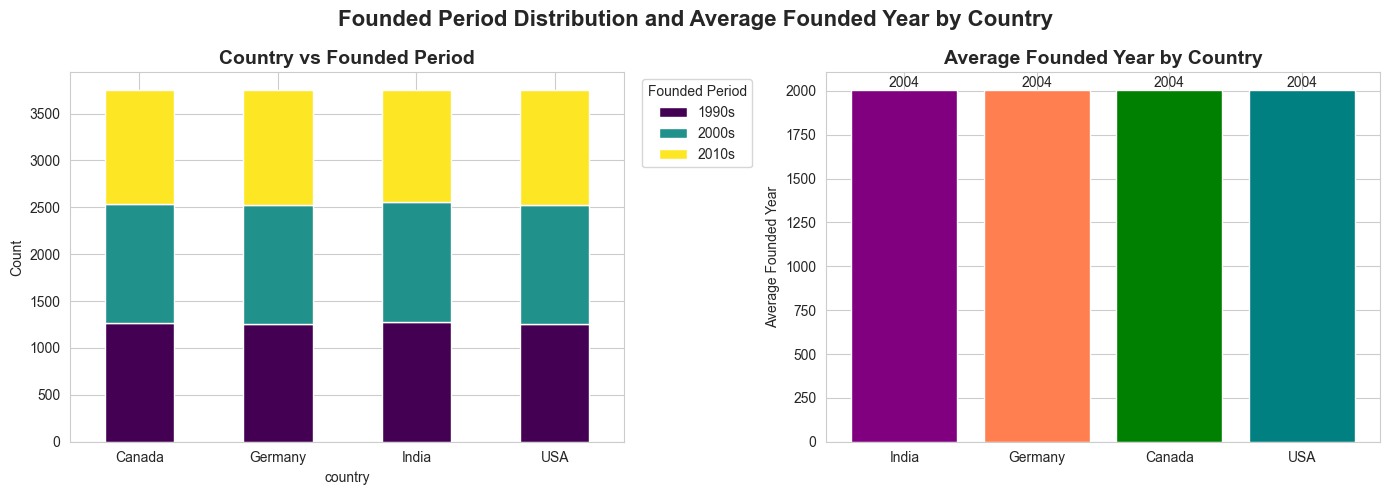

In [52]:
ct = pd.crosstab(df["country"], df["founded_period"])
display(ct)

avg_founded = df.groupby('country')['founded_year'].mean().sort_values()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# stacked
ct.plot(kind='bar', stacked=True, ax=ax[0], colormap='viridis')
ax[0].set_title('Country vs Founded Period', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Count')
ax[0].tick_params(rotation=0)
ax[0].legend(title='Founded Period', bbox_to_anchor=(1.02, 1))

#  bar 
colour = ['purple', 'coral', 'green', 'teal']
bars = ax[1].bar(avg_founded.index, avg_founded.values, color=colour)
ax[1].set_title('Average Founded Year by Country', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Average Founded Year')
ax[1].tick_params(axis='x', rotation=0)


for bar in bars:
    height = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2, height,f'{height:.0f}', ha='center', va='bottom')

# Global title
fig.suptitle('Founded Period Distribution and Average Founded Year by Country',fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


### `Founded Period Distribution and Average founded by Country`
### All four countries shows remarkably stable founding patterns across decade- no sharp spike or decline. the `2000s` represent the peak founding period globally, suggesting the wave of new business formation during the decade. the `2010s` shows slight decline, possibly due to market consolidation.

### The stacked bars confirm the uniform distribution seen in the table.Each country’s bar height and color segmentation are nearly identical.The yellow segment (2010s) is slightly smaller, visually emphasizing the mild slowdown in recent founding activity.

### All countries share an average founding year of 2004, indicating similar business maturity levels.This suggests that the dataset represents firms that are, on average, 20–25 years old, reflecting established organizations rather than startups.

### <mark> 3.5 Country vs Coustomer Count</mark>

customer_category,Very Low Customers,Low Customers,Medium Customers,High Customers,Very High Customers
country,,,,,
Canada,693,729,757,786,785
Germany,742,760,735,764,749
India,753,767,738,734,758
USA,727,748,800,740,735


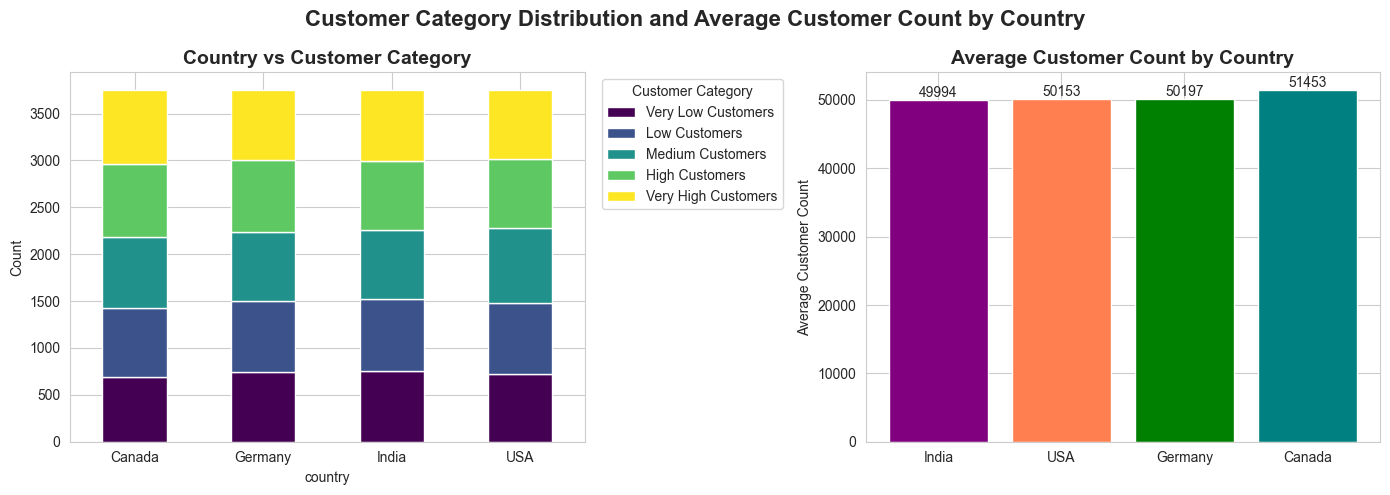

In [53]:
ct = pd.crosstab(df["country"], df["customer_category"])
display(ct)

avg_cust = df.groupby('country')['customer_count'].mean().sort_values()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# stacked 
ct.plot(kind='bar', stacked=True, ax=ax[0], colormap='viridis')
ax[0].set_title('Country vs Customer Category', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Count')
ax[0].tick_params(rotation=0)
ax[0].legend(title='Customer Category', bbox_to_anchor=(1.02, 1))

# bar
colour = ['purple', 'coral', 'green', 'teal']
bars = ax[1].bar(avg_cust.index, avg_cust.values, color=colour)
ax[1].set_title('Average Customer Count by Country', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Average Customer Count')
ax[1].tick_params(axis='x', rotation=0)


for bar in bars:
    height = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2, height,f'{height:.0f}', ha='center', va='bottom')


fig.suptitle('Customer Category Distribution and Average Customer Count by Country',fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


### `Customer Category distribution and Avg Customer Count by Country`
### All countries show similar total counts, suggesting comparable market sizes.`Canada` leads slightly in High and Very High categories, implying stronger customer penetration.`USA` stands out for its Medium customer segment, reflecting a robust middle‑tier customer base. `Germany` and `India` maintain balanced distributions, showing steady customer engagement across tiers.

### The average customer count varies only slightly, showing near‑parity in customer volume across countries. `Canada`’s lead suggests marginally larger customer bases per firm — possibly due to higher market penetration or broader service reach. `India`’s slightly lower average may reflect more fragmented customer pools or smaller firm sizes.

### The dataset reveals structural similarity across countries — no extreme skew toward low or high customer tiers.

### <mark>3.6 Country vs Market rating</mark>

rating_category,High,Low,Medium
country,,,
Canada,796,1414,1540
Germany,807,1450,1493
India,792,1454,1504
USA,807,1462,1481


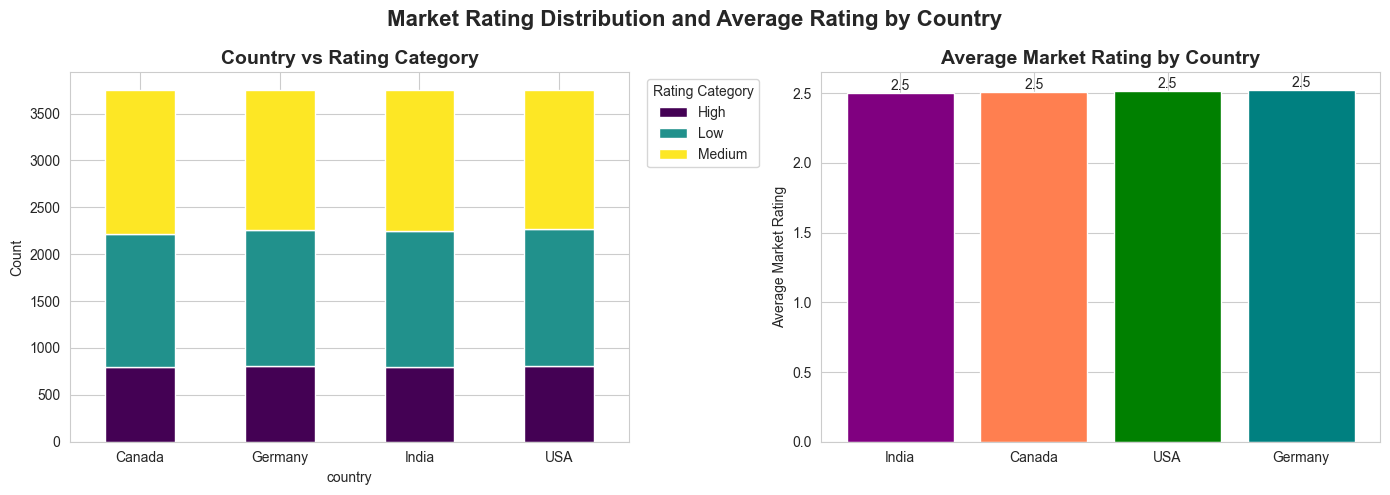

In [54]:
ct = pd.crosstab(df["country"], df["rating_category"])
display(ct)

avg_rating = df.groupby('country')['market_rating'].mean().sort_values()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# stacked
ct.plot(kind='bar', stacked=True, ax=ax[0], colormap='viridis')
ax[0].set_title('Country vs Rating Category', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Count')
ax[0].tick_params(rotation=0)
ax[0].legend(title='Rating Category', bbox_to_anchor=(1.02, 1))

#bar 
colour = ['purple', 'coral', 'green', 'teal']
bars = ax[1].bar(avg_rating.index, avg_rating.values, color=colour)
ax[1].set_title('Average Market Rating by Country', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Average Market Rating')
ax[1].tick_params(axis='x', rotation=0)


for bar in bars:
    height = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2, height,f'{height:.1f}', ha='center', va='bottom')

fig.suptitle('Market Rating Distribution and Average Rating by Country',fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


### `Market Rating Distribution and Avg Rating by Country`
### All countries show remarkably similar rating distributions, indicating comparable market sentiment.The `Medium` category dominates, suggesting most firms receive moderate ratings rather than extremes. The `Low` category is slightly larger than `High`, implying room for improvement in perceived market performance. `Germany` and `USA` have the most balanced profiles, reflecting stable reputations.

### The average rating is identical (2.5) across all countries, showing uniform market perception. The absence of variation implies no country significantly outperforms or underperforms in overall market rating.

### The dataset reveals global uniformity in market ratings — all countries share similar sentiment profiles.



## <mark>4. Employee Count</mark>

### <mark>4.1 Employee Count vs Annual Revenue Million</mark>

In [55]:
df["revenue_category"] = pd.cut(
    df["annual_revenue_million"],
    bins=[0, 250, 500, 750, 1000, 1100],
    labels=["0–250", "250–500", "500–750", "750–1000", "1000–1100"])

df['employee_size'] = pd.cut(
    df['employee_count'],
    bins=[0, 500, 1000, 2000, 3500, 6000],
    labels=["0–500", "500–1000", "1000–2000", "2000–3500", "3500–6000"])



revenue_category,0–250,250–500,500–750,750–1000,1000–1100
employee_size,,,,,
0–500,226,297,277,278,61
500–1000,262,371,373,363,93
1000–2000,619,797,748,758,154
2000–3500,905,1164,1129,1092,245
3500–6000,950,1216,1224,1129,269


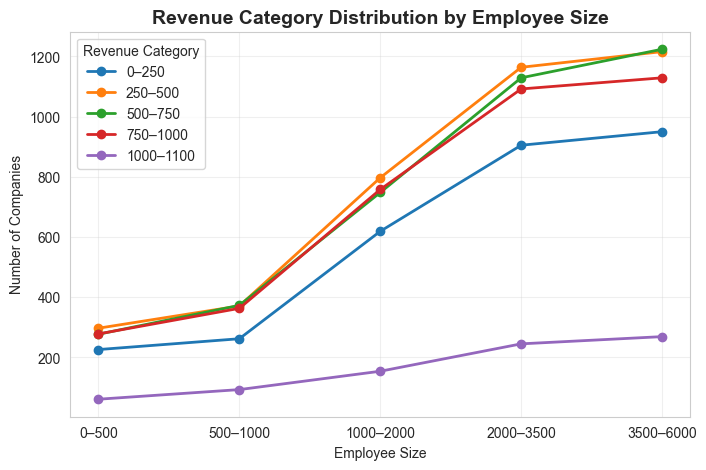

In [56]:
ct = pd.crosstab(df['employee_size'],df['revenue_category'])

display(ct)

plt.figure(figsize=(8,5))

for col in ct.columns:
    plt.plot(ct.index,ct[col],marker='o',linewidth=2,label=col)

plt.title('Revenue Category Distribution by Employee Size',fontsize=14,fontweight='bold')

plt.xlabel('Employee Size')
plt.ylabel('Number of Companies')

plt.legend(title='Revenue Category')
plt.grid(alpha=0.3)

plt.show()

### `Revenue Category Distribution by Employee Size`
### Across all employee bands, counts increase steadily as employee size increases. This is strong positive size-revenue relationship.

### Larger firms also contain many low-revenue companies, this means company size alone does not gurantee revenue efficiency.

### Scaling workforce does not automatically convert in to top tier reveue. Even the largest firms are not dominated by high revenue, most are still in mid-range bands(250-750).

### Very low and Very High revenue exists across all emploee size, indicates revenue not exclusively determined by company size. Companies of all sizes appear across all revenue bands.


### <mark>4.2 Employee Count vs Profit Margin (%)</mark>

profit_category,0–10%,10–20%,20–30%,30–40%,40–50%
employee_size,,,,,
0–500,12.38,24.58,25.55,26.16,11.33
500–1000,13.00,24.69,25.58,24.62,12.11
1000–2000,12.29,24.51,25.72,25.13,12.35
2000–3500,12.17,26.09,24.23,25.38,12.13
3500–6000,12.07,25.54,24.62,25.29,12.47


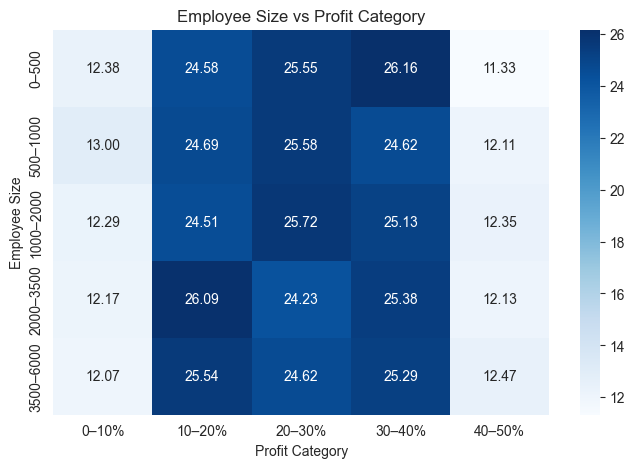

In [57]:
df['profit_category'] = pd.cut(
    df['profit_margin_percent'],
    bins=[0, 10, 20, 30, 40, 50],
    labels=["0–10%", "10–20%", "20–30%", "30–40%", "40–50%"])
ct = pd.crosstab(df['employee_size'],df['profit_category'], normalize='index')*100

display(ct.round(2))

plt.figure(figsize=(8,5))

sns.heatmap(ct, annot=True, fmt='.2f', cmap='Blues')

plt.title('Employee Size vs Profit Category')
plt.xlabel('Profit Category')
plt.ylabel('Employee Size')

plt.show()

### `Employee size vs Profit Category`
### Most companies operates in mid-efficicency profit zones, indicates industry compitition is balance and most firms converage towards normal profitability levels.

### Larger companies do not significantly outperforme smaller one in marginal efficiency. These firms have balanced but not superior margin distribution

### All employee size shows similar low margin propotion. Profit margin percent does not increases with employee size

### Companies grow in scales not in efficiency-profit margin remain almost identical across all employee size

### <mark>4.3 Employee Count vs Founded Period</mark>

founded_period,1990s,2000s,2010s
employee_size,,,
0–500,419,382,338
500–1000,490,495,477
1000–2000,1054,1013,1009
2000–3500,1525,1525,1485
3500–6000,1556,1682,1550


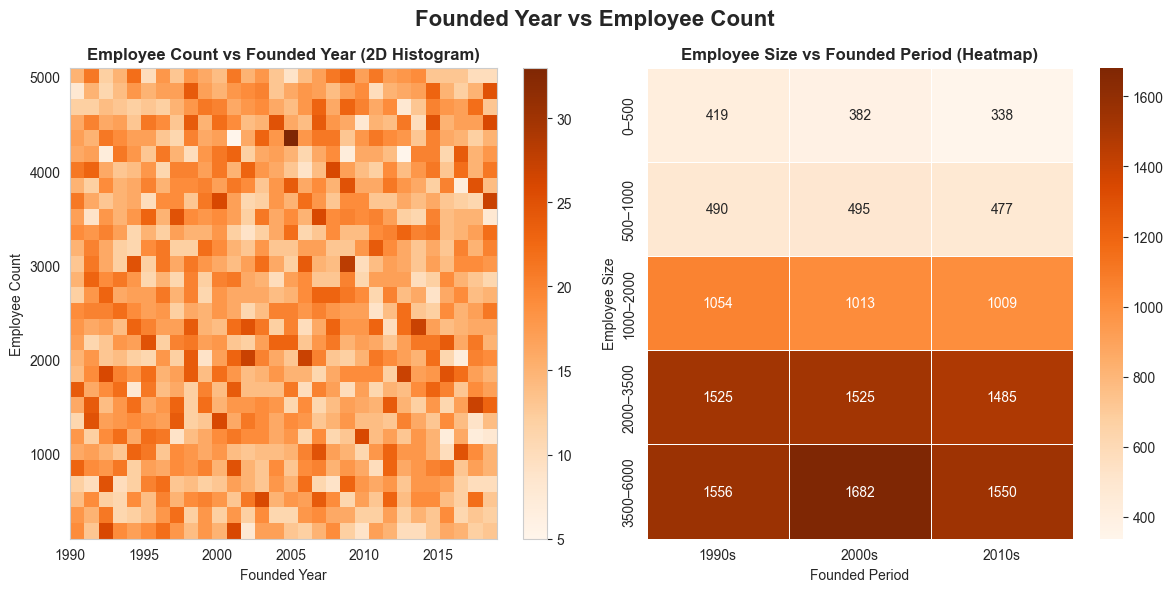

In [58]:
ct = pd.crosstab(df['employee_size'], df['founded_period'])
display(ct)
fig, ax = plt.subplots(1, 2, figsize=(12,6))

# histogram
hb = ax[0].hist2d(df['founded_year'], df['employee_count'],bins=(30, 30), cmap='Oranges')
ax[0].set_title('Employee Count vs Founded Year (2D Histogram)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Founded Year')
ax[0].set_ylabel('Employee Count')
fig.colorbar(hb[3], ax=ax[0])

# Heatmap
sns.heatmap(ct, annot=True, fmt='.0f', cmap='Oranges', linewidths=0.5, ax=ax[1])
ax[1].set_title('Employee Size vs Founded Period (Heatmap)', fontsize=12, fontweight='bold')
ax[1].set_ylabel('Employee Size')
ax[1].set_xlabel('Founded Period')

# Global title
fig.suptitle('Founded Year vs Employee Count', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


### `Founded Year vs Employee Count`
### dataset contains a substantial number of medium-to-large organizations.

### The 3500–6000 employee segment peaks in the 2000s (1682 companies). This is the highest count in the entire heatmap.

### There is a gradual decline acrosss decades for companiers with 0-500 employee, this may indicates the dataset contains fewer recently founded small firms.

### Companies with mid-sized employee shows very similar counts across the decade.

### The heatmap does not reveal extreme concentration in any one founding period.

### `2D Histogram` Employee counts are distributed across the entire range of founded years. No strong upward or downward trend is visible between founding year and employee count. Both small and large companies appear throughout the 1990–2019 period. Company size does not seem to depend solely on age.

### Comapny age has only a moderate influence on workforce size.Overall, employee counts does not influenced by company's founding year alone.


### <mark>4.4 Employee count vs customer count</mark>

customer_category,0–20K,20K–40K,40K–60K,60K–80K,80K–120K
employee_size,,,,,
0–500,208,217,239,239,236
500–1000,296,279,283,300,304
1000–2000,585,621,621,616,633
2000–3500,882,909,938,926,880
3500–6000,944,978,949,943,974


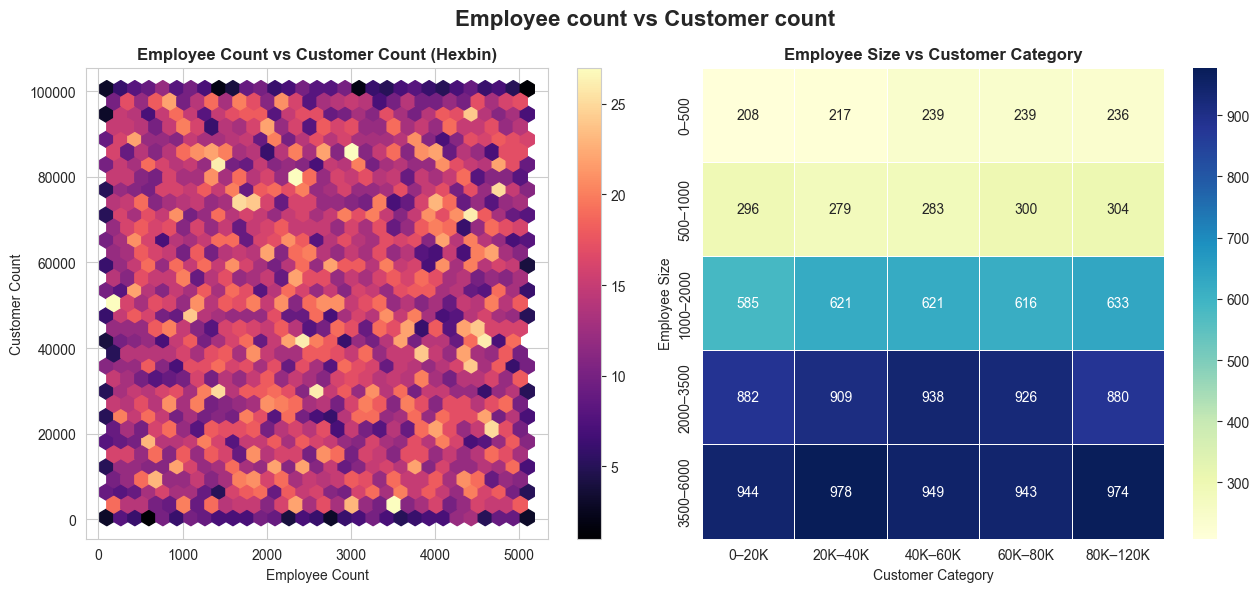

In [59]:
df['customer_category'] = pd.cut(
    df['customer_count'],
    bins=[0, 20000, 40000, 60000, 80000, 120000],
    labels=["0–20K", "20K–40K", "40K–60K", "60K–80K", "80K–120K"])

ct = pd.crosstab(df['employee_size'], df['customer_category'])

display(ct)

fig, ax = plt.subplots(1, 2, figsize=(13,6))

# Hexbin
hb = ax[0].hexbin(df['employee_count'],df['customer_count'],gridsize=30,cmap='magma',mincnt=1)
ax[0].set_title('Employee Count vs Customer Count (Hexbin)',fontsize=12,fontweight='bold')
ax[0].set_xlabel('Employee Count')
ax[0].set_ylabel('Customer Count')
fig.colorbar(hb, ax=ax[0])

#  Heatmap
sns.heatmap(ct,annot=True,fmt='d',cmap='YlGnBu',linewidths=0.5,ax=ax[1])
ax[1].set_title('Employee Size vs Customer Category',fontsize=12,fontweight='bold')
ax[1].set_xlabel('Customer Category')
ax[1].set_ylabel('Employee Size')
fig.suptitle('Employee count vs Customer count',fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

### `Employee Count vs Customer Count`
### The highest  customer counts consistently occur in the larger employee-size groups, this suggests that larger workforces are associated with larger customer bases.

### Across most employee-size bands, counts remain relatively stable across customer categories, this indicates that companies of a given size serve a wide range of customer volumes rather than clustering in one customer segment.

### The **0–500 employee** category has the smallest counts across all customer categories ranges from **208 to 239 companies**. Compared with the largest employee-size category (944–978 companies), the difference is substantial, this suggests customer acquisition capacity generally increases with workforce size.

### Companies with employee size 1000-2000 and 2000-3500 show a strong increase in counts compared to smaller and larger firms.

### No single customer category dramatically exceeds the others. The heatmap values are fairly balanced horizontally. This suggests the dataset was designed with a relatively uniform distribution of customer counts.

### `Hexbin Plot`

### Customer counts are spread throughout the full employee-count range. Both low and high customer counts appear for almost every employee-size level. There is no obvious upward trend line.

### The darkest hexagons appear around employee count: **1,000–4,500** and Customer count: **20,000–80,000**. This represents the most common company profile in the dataset.

### Even companies with moderate employee counts appear in higher customer categories. This suggests workforce size alone does not determine customer reach. The analysis indicates a positive association between company size and customer reach, as larger employee-size groups contain substantially more companies. However, the hexbin plot shows that customer count is not determined solely by workforce size. Companies with similar employee counts can serve very different numbers of customers, implying that factors such as technology, operational efficiency, business model, and market presence play an important role in customer acquisition and retention.


### <mark>4.5 Employee count vs Market Rating</mark>

rating_category,Low,Medium,High
employee_size,,,
0–500,410,468,261
500–1000,584,561,317
1000–2000,1180,1230,666
2000–3500,1720,1867,948
3500–6000,1886,1892,1010


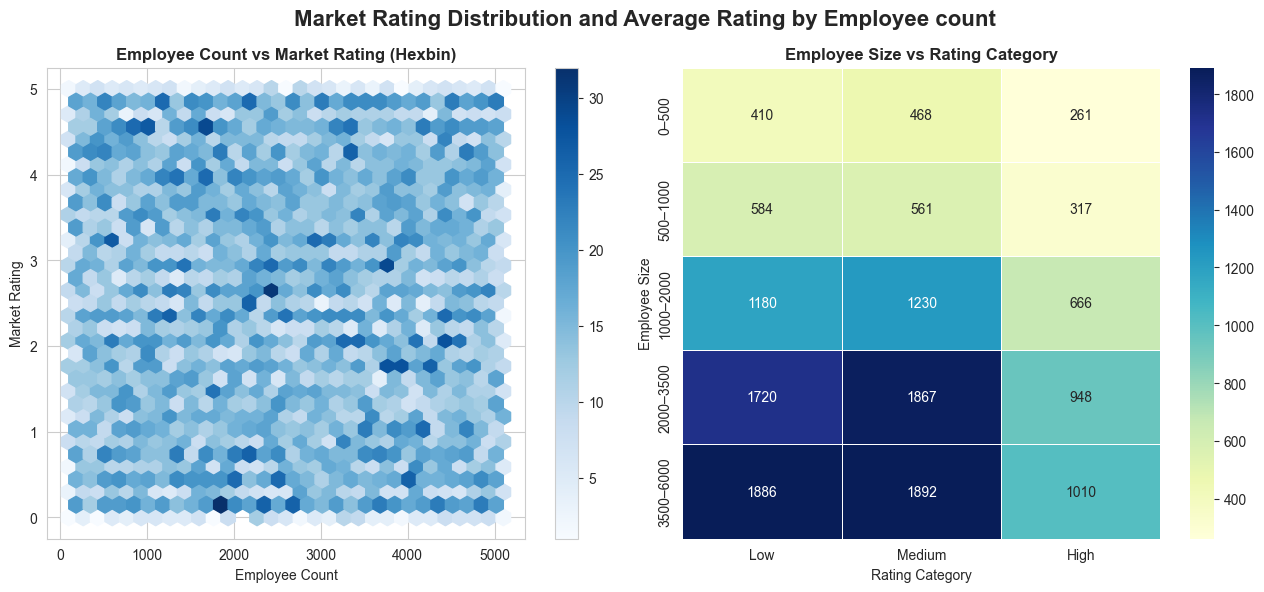

In [60]:
df['rating_category'] = pd.Categorical(
    df['rating_category'],
    categories=['Low', 'Medium', 'High'],
    ordered=True)

ct = pd.crosstab(df['employee_size'], df['rating_category'])
ct = ct[['Low', 'Medium', 'High']]

display(ct)

fig, ax = plt.subplots(1, 2, figsize=(13, 6))

# Hexbin
hb = ax[0].hexbin(df['employee_count'],df['market_rating'],gridsize=30,cmap='Blues',mincnt=1)
ax[0].set_title('Employee Count vs Market Rating (Hexbin)',fontsize=12,fontweight='bold')
ax[0].set_xlabel('Employee Count')
ax[0].set_ylabel('Market Rating')
fig.colorbar(hb, ax=ax[0])

# Heatmap
sns.heatmap(ct,annot=True,fmt='d',cmap='YlGnBu',linewidths=0.5,ax=ax[1])
ax[1].set_title('Employee Size vs Rating Category',fontsize=12,fontweight='bold')
ax[1].set_xlabel('Rating Category')
ax[1].set_ylabel('Employee Size')

fig.suptitle('Market Rating Distribution and Average Rating by Employee count',fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

### `Employee Count vs Market Rating`

### For every employee-size category, Medium-rated companies have the highest counts. This suggests most companies achieve average market performance rather than extremely high ratings.

### Across all employee-size categories, the `High rating` segment has the lowest count, suggesting achieving a high market rating appears relatively uncommon regardless of company size.

### Rating counts for all categories increase steadily as employee size increases. This indicates larger companies form a significant portion of the dataset and participate across all rating levels.

### High-rated companies counts rise from 261 to 1010 as employee size ioncreses from 500-6000. However, High-rated companies still represent a smaller share than Medium-rated companies.

### `Hexbin Plot`: Market ratings are spread across the entire employee-count range. There is no clear upward trend indicating that larger companies consistently receive higher ratings. Extremely low and extremely high ratings are less concentrated.

### Companies with similar employee counts can have very different market ratings. This suggests ratings are influenced by factors beyond workforce size. The analysis indicates that employee count has limited influence on market rating. Most organizations, regardless of size, fall into the Medium rating category.


## <mark>5. Annual Revenue Million</mark>

### <mark>5.1 Annual revenue vs Profit margin percent</mark>

profit_category,0–10%,10–20%,20–30%,30–40%,40–50%
revenue_category,,,,,
0–250,391,724,722,756,369
250–500,457,961,907,1022,498
500–750,482,942,963,934,430
750–1000,418,948,928,890,436
1000–1100,91,226,214,191,100


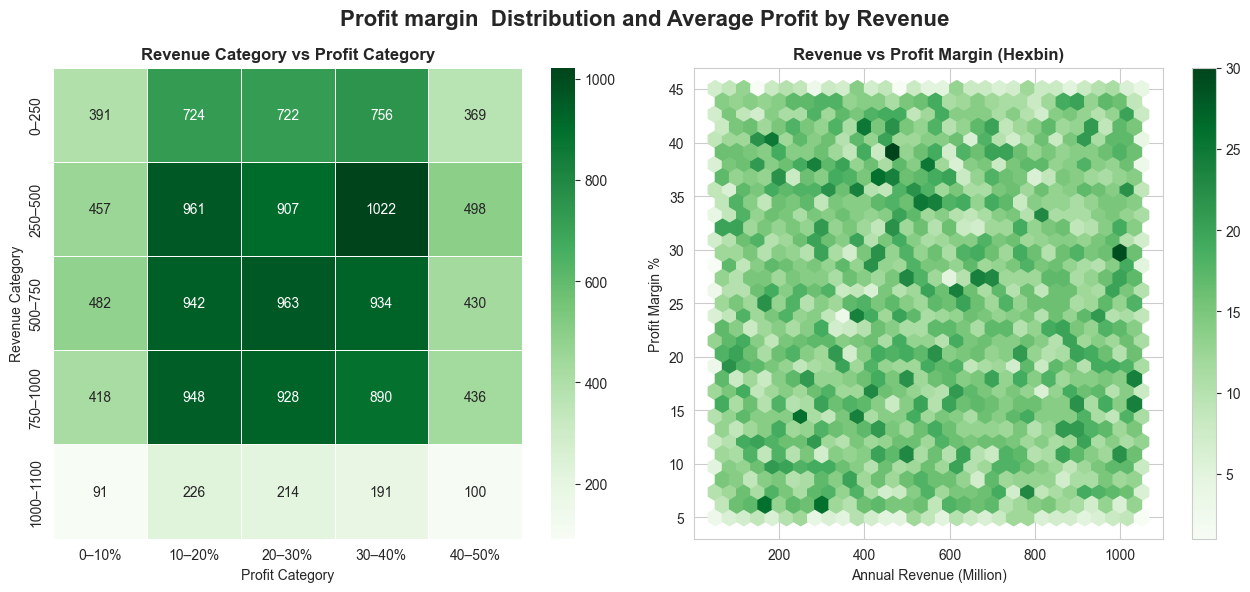

In [61]:
ct2 = pd.crosstab(df['revenue_category'], df['profit_category'])
display(ct2)

fig, ax = plt.subplots(1, 2, figsize=(13,6))

# Heatmap 
sns.heatmap(ct2,annot=True,fmt='d',cmap='Greens',linewidths=0.5,ax=ax[0])
ax[0].set_title('Revenue Category vs Profit Category', fontweight='bold')
ax[0].set_xlabel('Profit Category')
ax[0].set_ylabel('Revenue Category')

#  Hexbin
hb = ax[1].hexbin(df['annual_revenue_million'],df['profit_margin_percent'],gridsize=30,cmap='Greens',mincnt=1)
ax[1].set_title('Revenue vs Profit Margin (Hexbin)', fontweight='bold')
ax[1].set_xlabel('Annual Revenue (Million)')
ax[1].set_ylabel('Profit Margin %')
fig.colorbar(hb, ax=ax[1])

fig.suptitle('Profit margin  Distribution and Average Profit by Revenue',fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

### `Revenue vs Profit Margin`

### Revenue categories 250–500M, 500–750M, and 750–1000M contain the largest counts across nearly all profit-margin groups. The highest cell in the heatmap is `1022 companies` with revenue 250–500M and profit margin 30–40%.

### Very high profit margins  and  Low profit margins are relatively uncommon. Counts drop noticeably in the 40–50% category  and 0-10% category across all revenue groups. This suggests relatively few companies are operating with very weak  and very high profitability.

### Higher revenue does not necessarily mean higher profit margins. The distribution of profit categories remains fairly similar across revenue bands. Companies with high revenue appear in both low and high profit-margin groups. This indicates that revenue growth alone does not guarantee better profitability.

### `Hexbin Plot`: strong linear relationship between revenue and profit margin. Profit margins are spread across the full revenue range. There is no visible upward trend suggesting that profit margins increase as revenue increases. Dense hexagons are scattered throughout the chart rather than forming a clear pattern. This suggests profitability is  not solely driven by revenue size.
 
### Firms in nearly every revenue category are represented in the 30–40% and 40–50% profit-margin bands. This indicates that both smaller and larger firms can operate efficiently. The analysis suggests that **revenue and profit margin have a weak relationship**. Most companies achieve **moderate profit margins between 10% and 40%**, regardless of revenue size. 

### <mark>5.2 Annual revenue vs Founded year</mark>

revenue_category,0–250,250–500,500–750,750–1000,1000–1100
founded_period,,,,,
1990s,1019,1267,1239,1252,267
2000s,988,1287,1326,1188,308
2010s,955,1291,1186,1180,247


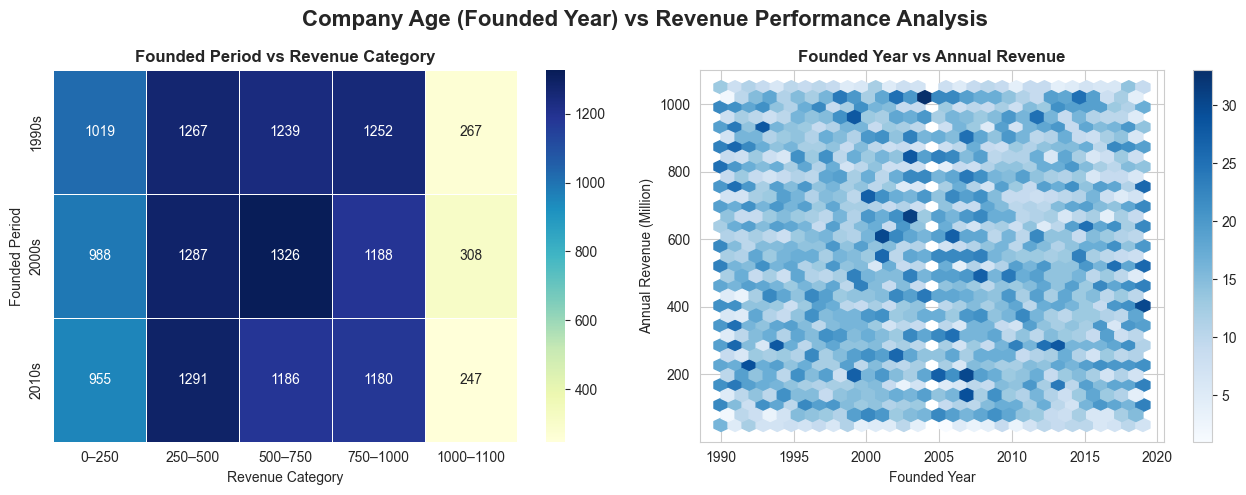

In [62]:
ct3 = pd.crosstab(df['founded_period'], df['revenue_category'])
display(ct3)

fig, ax = plt.subplots(1, 2, figsize=(13,5))

# Heatmap
sns.heatmap(ct3,annot=True,fmt='d',cmap='YlGnBu',linewidths=0.5,ax=ax[0])
ax[0].set_title('Founded Period vs Revenue Category', fontweight='bold')
ax[0].set_xlabel('Revenue Category')
ax[0].set_ylabel('Founded Period')

# Hexbine
hb = ax[1].hexbin(df['founded_year'],df['annual_revenue_million'],gridsize=30,cmap='Blues',mincnt=1)
ax[1].set_title('Founded Year vs Annual Revenue', fontweight='bold')
ax[1].set_xlabel('Founded Year')
ax[1].set_ylabel('Annual Revenue (Million)')
fig.colorbar(hb, ax=ax[1])

fig.suptitle('Company Age (Founded Year) vs Revenue Performance Analysis',fontsize=16,fontweight='bold')

plt.tight_layout()
plt.show()

### `company age relates to revenue performance`  

### `Heatmap`
- Across all decades, most companies fall in the `250–750M` revenue range, showing consistent mid‑tier performance regardless of age.  
- 2010s cohort shows marginally lower counts in the top revenue brackets (750–1100M), suggesting that younger firms haven’t yet scaled to the same revenue levels as older ones.  
- Firms founded in the `2000s` lead slightly in the 500–750M range, indicating that this decade produced many mature, revenue‑stable businesses.  
- Across all periods, the 1000–1100M category remains sparse (≈250–300 firms), implying that only a small fraction achieve very high annual revenue.

### `Hexbin`
- The hexbin shows a fairly even spread of companies from 1990–2020, meaning founding year alone doesn’t strongly determine revenue scale.  
- Revenue doesn’t systematically increase for newer firms, reinforcing that age isn’t the sole driver of revenue growth — other factors like market maturity or sector specialization likely matter more.

### Older firms (1990s–2000s) dominate the mid‑to‑high revenue tiers, while newer firms (2010s) are still building scale. The pattern suggests steady market saturation rather than exponential growth among newer entrants.

### <mark>5.3 Annual revenue vs Customer Count</mark>

customer_category,0–20K,20K–40K,40K–60K,60K–80K,80K–120K
revenue_category,,,,,
0–250,616,568,598,577,603
250–500,724,744,781,775,821
500–750,759,766,736,744,746
750–1000,656,760,745,757,702
1000–1100,160,166,170,171,155


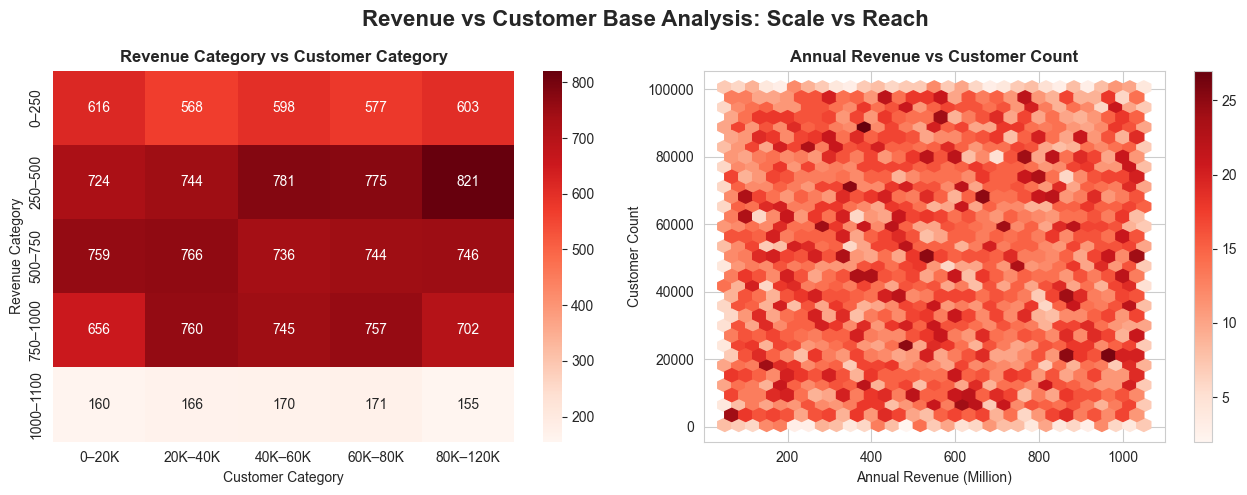

In [63]:
ct = pd.crosstab(df['revenue_category'], df['customer_category'])
display(ct)

fig, ax = plt.subplots(1, 2, figsize=(13,5))

# Heatmap 
sns.heatmap(ct,annot=True,fmt='d',cmap='Reds',ax=ax[0])
ax[0].set_title('Revenue Category vs Customer Category', fontweight='bold')
ax[0].set_xlabel('Customer Category')
ax[0].set_ylabel('Revenue Category')


# Hexbin 
hb = ax[1].hexbin(df['annual_revenue_million'],df['customer_count'],gridsize=30,cmap='Reds',mincnt=1)
ax[1].set_title('Annual Revenue vs Customer Count', fontweight='bold')
ax[1].set_xlabel('Annual Revenue (Million)')
ax[1].set_ylabel('Customer Count')

fig.colorbar(hb, ax=ax[1])

fig.suptitle('Revenue vs Customer Base Analysis: Scale vs Reach',fontsize=16,fontweight='bold')

plt.tight_layout()
plt.show()

### `Revenue Category vs Customer Category`

### `Heatmap`
- The `250–750M revenue bands` dominate across all customer categories, peaking at **821 firms** in the `250–500M` range with 80K–120K customers. This suggests that mid‑revenue companies tend to have broad customer bases.  
- Counts remain steady but slightly taper off in the `750–1000M` range, implying that scaling revenue beyond 750M doesn’t necessarily expand customer reach proportionally.  
- The `1000–1100M` category shows very low counts, indicating that only a small fraction of firms achieve both high revenue and large customer bases — likely specialized or enterprise‑focused players.  

### `Hexbin`
- The hexbin shows a fairly even spread, meaning revenue and customer count are not tightly correlated — firms with similar revenue can have vastly different customer bases.  
- The densest clusters lie around `200–800M revenue` and `20K–80K customers`, reinforcing the mid‑scale dominance seen in the heatmap.  
- Few firms exist at both very low and very high ends of revenue or customer count, suggesting market consolidation around mid‑range performance.

### The data indicates a broad middle market where most firms balance moderate revenue and customer reach. High revenue does not necessorily mean high customer count — top performers may rely on premium pricing or niche segments rather than mass reach. The mid‑tier `250–750M` segment represents the most competitive and populated zone, likely driving the bulk of industry activity.  

### <mark>5.4 Annual revenue vs Market Rating</mark>

rating_category,Low,Medium,High
revenue_category,,,
0–250,1138,1208,616
250–500,1501,1535,809
500–750,1470,1468,813
750–1000,1365,1476,779
1000–1100,306,331,185


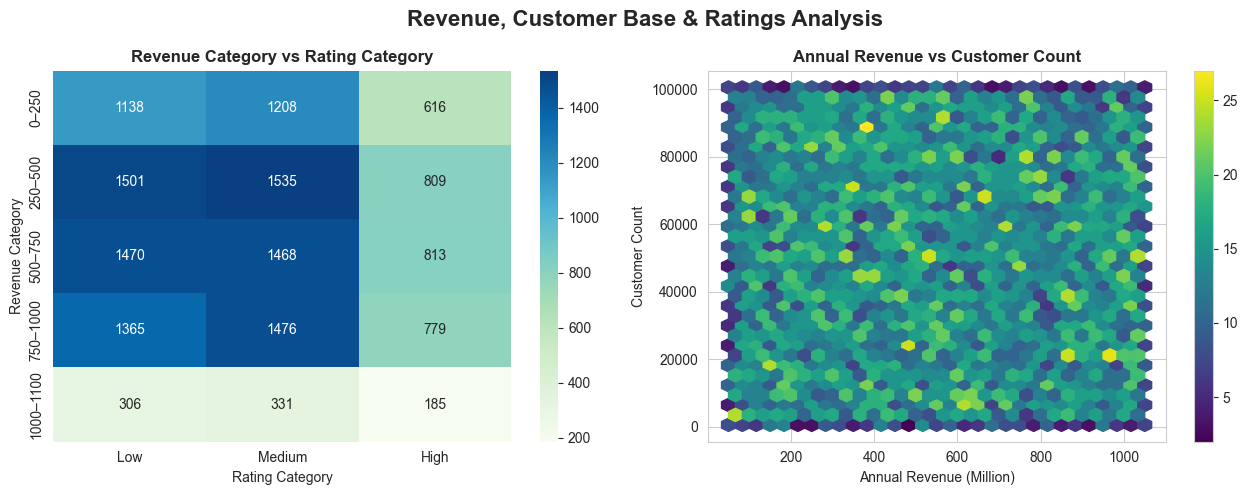

In [64]:
ct_rating = pd.crosstab(df['revenue_category'], df['rating_category'])
display(ct_rating)

fig, ax = plt.subplots(1, 2, figsize=(13,5))

#Heatmap
sns.heatmap(ct_rating, annot=True, fmt='d', cmap='GnBu', ax=ax[0])
ax[0].set_title('Revenue Category vs Rating Category', fontweight='bold')
ax[0].set_xlabel('Rating Category')
ax[0].set_ylabel('Revenue Category')

# hexbin
hb = ax[1].hexbin(df['annual_revenue_million'], df['customer_count'],gridsize=30, cmap='viridis', mincnt=1)
ax[1].set_title('Annual Revenue vs Customer Count', fontweight='bold')
ax[1].set_xlabel('Annual Revenue (Million)')
ax[1].set_ylabel('Customer Count')

fig.colorbar(hb, ax=ax[1])

fig.suptitle('Revenue, Customer Base & Ratings Analysis', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


### `Revenue Category vs Rating Category`
### `Heatmap`
- The `250–750M` revenue bands dominate across all rating categories. This indicates that most companies operate in a stable mid‑revenue zone with moderate ratings — a sign of market maturity. 
- Across all revenue tiers, the `Medium rating` category consistently edges out Low and High ratings, suggesting that firms with balanced performance and customer satisfaction are most common.  
- The `High rating` column shows significantly fewer firms roughly half of Medium counts, implying that achieving top ratings remains challenging even for high‑revenue companies.  
- The 1000–1100M bracket shows a steep drop in counts across all ratings — only ~300 firms — highlighting that very few reach elite revenue levels, regardless of rating quality.

### `Hexbin`
- The hexbin shows a uniform spread of firms across revenue and customer count, meaning revenue growth doesn’t directly correlate with customer volume.  
- Most firms cluster between `200–800M` revenue and `20K–80K` customers, reinforcing the mid‑market dominance seen in the heatmap.  
- Few firms exist at both very low and very high ends of revenue or customer count — indicating that startups and large enterprises are less frequent compared to mid‑scale players.

### The data suggests a broad middle market where firms achieve moderate ratings and revenue stability. High ratings don’t guarantee high revenue. Firms aiming for growth should focus on quality improvement and customer satisfaction, as the “Medium rating plateau” shows untapped potential for upward movement. 

## <mark>6. Profit Margin Percent</mark>

### <mark>6.1 Profit Margin Percent vs Founded Year</mark>

founded_period,1990s,2000s,2010s
profit_category,,,
0–10%,611,634,594
10–20%,1320,1297,1184
20–30%,1224,1277,1233
30–40%,1278,1290,1225
40–50%,611,599,623


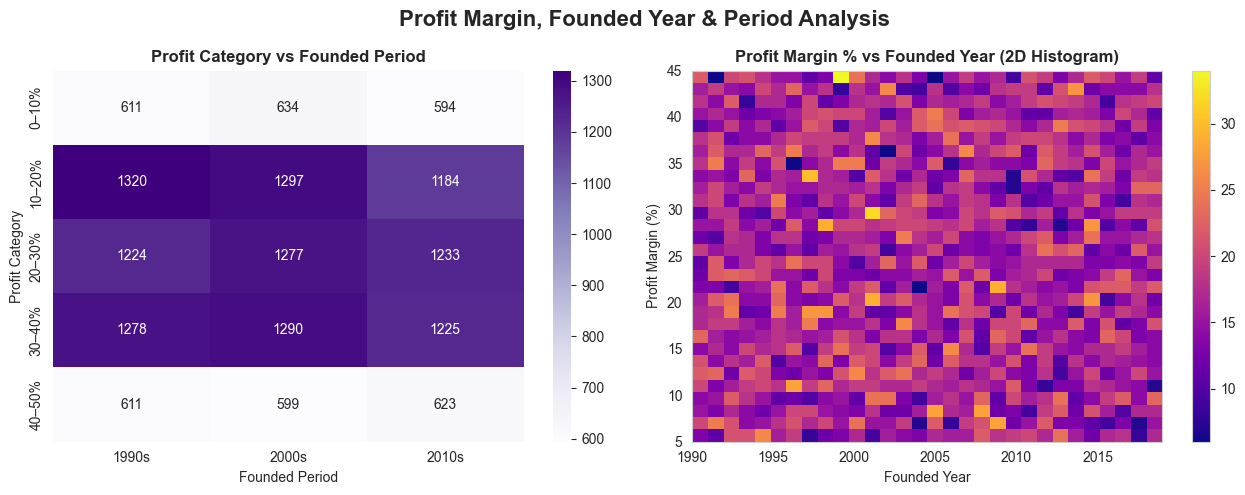

In [65]:
ct_profit_period = pd.crosstab(df['profit_category'], df['founded_period'])
display(ct_profit_period)

fig, ax = plt.subplots(1, 2, figsize=(13,5))

# Heatmap
sns.heatmap(ct_profit_period, annot=True, fmt='d', cmap='Purples', ax=ax[0])
ax[0].set_title('Profit Category vs Founded Period', fontweight='bold')
ax[0].set_xlabel('Founded Period')
ax[0].set_ylabel('Profit Category')

# 2D Histogram
hb = ax[1].hist2d(df['founded_year'], df['profit_margin_percent'],bins=(30,30), cmap='plasma')
ax[1].set_title('Profit Margin % vs Founded Year (2D Histogram)', fontweight='bold')
ax[1].set_xlabel('Founded Year')
ax[1].set_ylabel('Profit Margin (%)')
fig.colorbar(hb[3], ax=ax[1])

fig.suptitle('Profit Margin, Founded Year & Period Analysis', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

### `Profit Category vs Founded Period`
### `Heatmap`
- Across all decades, the `10–40%` profit margin bands account for the majority of firms, with counts consistently above 1,200. This indicates a strong concentration of companies operating at sustainable profitability levels rather than extremes.  
- The distribution remains remarkably consistent from the 1990s to 2010s, suggesting that founding period has limited influence on profit margin performance — profitability patterns are structurally stable over time.  
- The `0–10%` and `40–50%` categories show much smaller counts comared to other categories, implying that very low or very high profit margins are rare. This reflects a mature market where most firms cluster around moderate efficiency levels.  
- The `2010s` show marginally lower counts in the `10–40%` range, hinting that younger firms may still be optimizing operations or scaling toward profitability.

### `2D Histogram`
- The histogram shows no strong trend between founding year and profit margin — companies founded in different years exhibit similar profit distributions.    
- Few firms achieve margins below 10% or above 40%, confirming that extreme profitability or inefficiency is uncommon.  
- The absence of visible upward or downward trends suggests that profitability is driven more by operational factors than by company age.

### The data reveals a mature, efficiency‑driven market, where most firms sustain moderate profitability regardless of founding era. Newer firms (2010s) may benefit from focusing on scaling and margin improvement strategies to match the profitability stability of older cohorts. The overall pattern underscores industry equilibrium— profitability has plateaued, signaling a competitive but stable environment.

### <mark>6.2 Profit Margin Percent vs Customer Count</mark>

customer_category,0–20K,20K–40K,40K–60K,60K–80K,80K–120K
profit_category,,,,,
0–10%,369,376,368,346,380
10–20%,767,742,786,743,763
20–30%,713,758,743,755,765
30–40%,732,742,760,805,754
40–50%,334,386,373,375,365


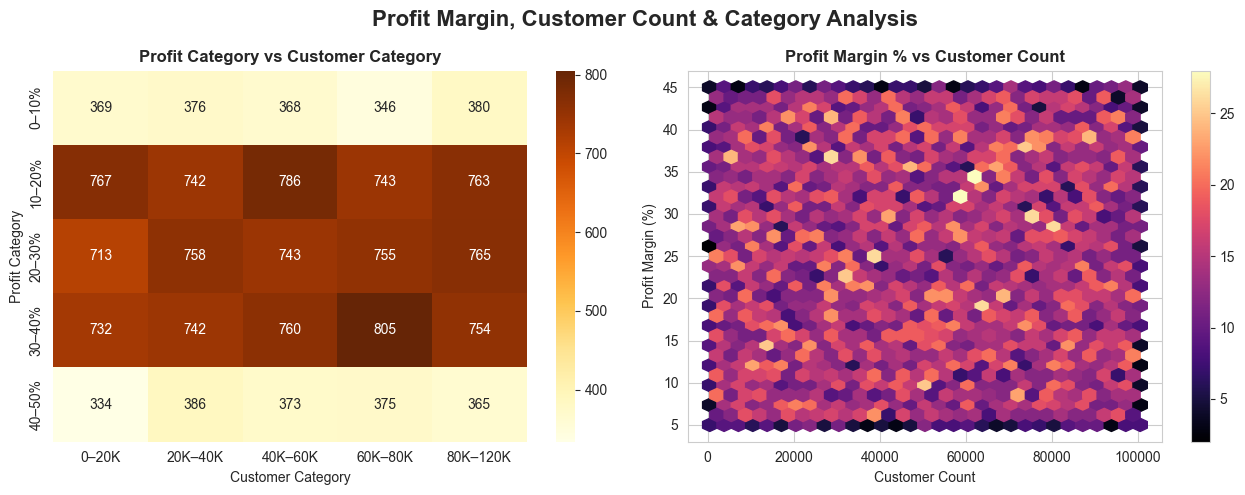

In [66]:
ct_profit_customer = pd.crosstab(df['profit_category'], df['customer_category'])
display(ct_profit_customer)

fig, ax = plt.subplots(1, 2, figsize=(13,5))

# Heatmap
sns.heatmap(ct_profit_customer, annot=True, fmt='d', cmap='YlOrBr', ax=ax[0])
ax[0].set_title('Profit Category vs Customer Category', fontweight='bold')
ax[0].set_xlabel('Customer Category')
ax[0].set_ylabel('Profit Category')

# Hexbin
hb = ax[1].hexbin(df['customer_count'], df['profit_margin_percent'], gridsize=30, cmap='magma', mincnt=1)
ax[1].set_title('Profit Margin % vs Customer Count', fontweight='bold')
ax[1].set_xlabel('Customer Count')
ax[1].set_ylabel('Profit Margin (%)')
fig.colorbar(hb, ax=ax[1])

fig.suptitle('Profit Margin, Customer Count & Category Analysis',fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

### `Profit Category vs Customer Category`
### `Heatmap`
- The `10–40%` profit margin bands account for the majority of firms across all customer categories, with counts consistently between `740–805`. This indicates that most companies operate at sustainable profitability levels while serving moderate to large customer bases.  
- The `30–40%` profit margin group with `60K–80K` customers represents the most balanced performance — firms here achieve strong profitability without sacrificing customer volume. This segment likely reflects mature, well‑optimized businesses.  
- The counts remain relatively even across customer categories, suggesting that profitability isn’t strongly dependent on customer scale. Firms with smaller bases (20K–40K) perform comparably to those with larger ones (80K–120K).  
- The `0–10%` and `40–50%` categories show significantly fewer firms, implying that both underperforming and highly profitable extremes are rare. This reflects a competitive equilibrium where most firms cluster around moderate margins.  

### `Hexbin`
- The hexbin shows a broad, even spread of firms across customer counts and profit margins, confirming that customer volume doesn’t directly drive profitability.  
- The highest density lies between `10–35%` profit margins and `20K–80K` customers, reinforcing the mid‑range dominance seen in the heatmap.  
- Few firms exist at very low (<10%) or very high (>40%) margins, and at extreme customer counts (>100K), indicating that both hyper‑growth and low‑efficiency models are uncommon.  
- The absence of strong vertical or horizontal clustering suggests that firms maintain similar profitability structures regardless of customer scale — a hallmark of mature market behavior.

### The data reveals a balanced market structure where most firms sustain moderate profitability across diverse customer bases.Firms with `60K–80K` customers and `30–40%` margins exemplify the ideal balance between reach and return. The scarcity of high‑margin firms (>40%) suggests limited differentiation or pricing power in the market — an opportunity for innovation, premium positioning, or value‑added services. Conversely, the low‑margin segment (<10%) may represent new entrants or inefficient operators, highlighting potential consolidation or improvement zones. Overall, the pattern underscores a mature, competitive ecosystem where profitability is stable but incremental gains depend on operational excellence rather than customer expansion.

### <mark>6.3 Profit Margin Percent vs Market Rating</mark>

rating_category,Low,Medium,High
profit_category,,,
0–10%,659,770,410
10–20%,1507,1452,842
20–30%,1499,1485,750
30–40%,1422,1568,803
40–50%,693,743,397


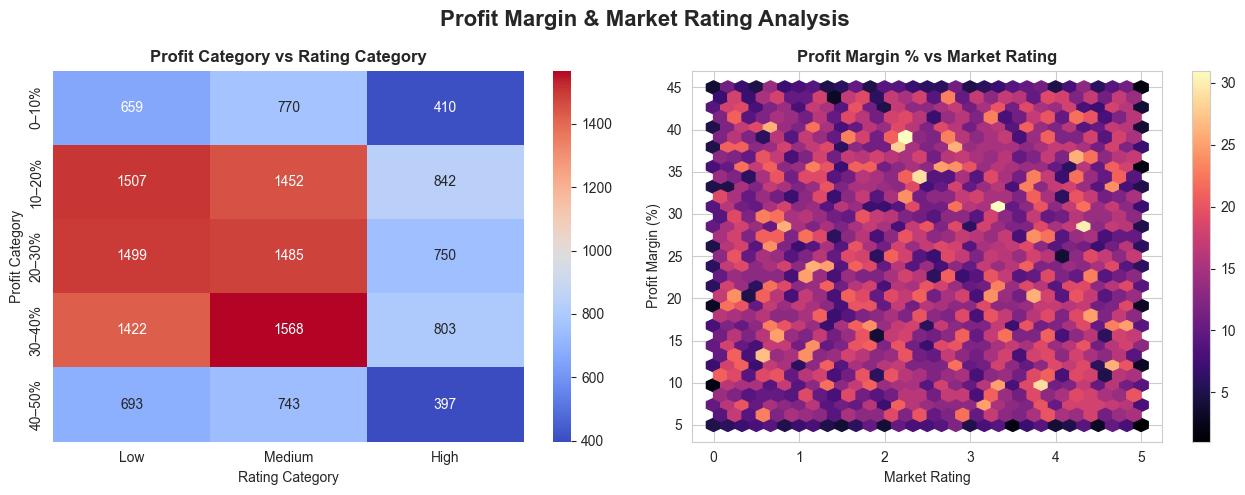

In [67]:
ct_profit_rating = pd.crosstab(df['profit_category'], df['rating_category'])
display(ct_profit_rating)

fig, ax = plt.subplots(1, 2, figsize=(13,5))

# Heatmap
sns.heatmap(ct_profit_rating, annot=True, fmt='d', cmap='coolwarm', ax=ax[0])
ax[0].set_title('Profit Category vs Rating Category', fontweight='bold')
ax[0].set_xlabel('Rating Category')
ax[0].set_ylabel('Profit Category')

# Hexbing
hb = ax[1].hexbin(df['market_rating'], df['profit_margin_percent'],gridsize=30, cmap='magma', mincnt=1)
ax[1].set_title('Profit Margin % vs Market Rating', fontweight='bold')
ax[1].set_xlabel('Market Rating')
ax[1].set_ylabel('Profit Margin (%)')

fig.colorbar(hb, ax=ax[1])

fig.suptitle('Profit Margin & Market Rating Analysis',fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


###  `Profit Category vs Rating Category`
### `Heatmap` 
- Across all profit tiers, the `Medium rating` category consistently records the highest counts- peaking at `1568` in the `30–40%` margin band. This suggests that firms with balanced performance and reputation are most prevalent — a hallmark of market maturity.  
- The `High rating` column shows significantly fewer firms roughly half of Medium counts, implying that achieving top market ratings remains challenging even for profitable companies.  
- The `Low rating` group closely follows Medium in volume, indicating that profitability alone doesn’t guarantee higher ratings — other factors like customer satisfaction, brand perception, or innovation likely play a role.  
- The `40–50%` margin band shows a sharp decline across all ratings, confirming that very high profitability is uncommon and possibly constrained by market competition or cost structures.

### `Hexbin`
- The hexbin shows a broad, even spread of firms across market ratings and profit margins, meaning profitability and ratings are not tightly correlated.  
- The highest density lies between `10–35%` margins and ratings `1–4`, reinforcing the mid‑range dominance seen in the heatmap.  
- Few firms exist at both very low (<10%) or very high (>40%) margins, and at extreme ratings (near 0 or 5), suggesting that both underperforming and elite performers are rare.  
- The absence of strong vertical or horizontal clustering implies that firms maintain similar profitability structures regardless of rating — a sign of competitive equilibrium.

### The data reveals a balanced market structure where most firms sustain moderate profitability and mid‑level ratings. High profits don’t necessarily translate into high ratings. The elite segment (High rating + 30–40% margin) represents an aspirational benchmark: profitable yet well‑rated firms that likely combine operational efficiency with strong market credibility.  Overall, the pattern underscores a mature, competitive ecosystem where incremental gains depend on strategic branding and customer‑centric excellence rather than margin expansion alone.

## <mark>7. Founded Year</mark>

### <mark>7.1 Founded year vs Customer Count</mark>

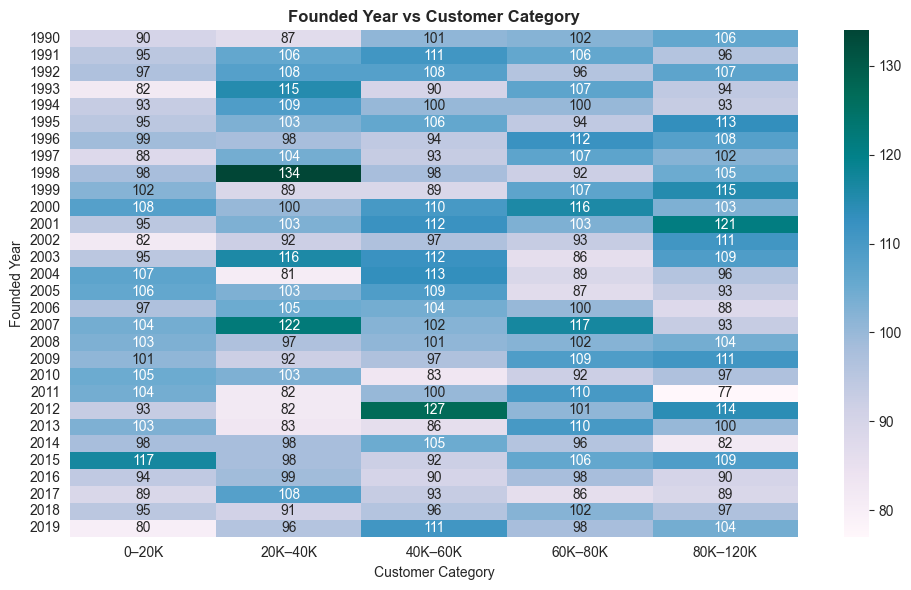

In [68]:
ct_year_customer = pd.crosstab(df['founded_year'], df['customer_category'])
# display(ct_year_customer)

plt.figure(figsize=(10,6))
sns.heatmap(ct_year_customer, annot=True, fmt='d', cmap='PuBuGn')

plt.title('Founded Year vs Customer Category', fontweight='bold')
plt.xlabel('Customer Category')
plt.ylabel('Founded Year')

plt.tight_layout()
plt.show()

### `Founded Year vs Customer Category`

### Customer distribution is remarkably consistent across years. Most values fall between `80 and 120` companies in every customer category. No single founded year dominates any customer segment. This indicates a balanced distribution of customer counts across company ages.

### No clear trend between company age and customer base size. Older companies (1990s) and newer companies (2010s) appear across all customer categories. This suggests that being older does not automatically result in a larger customer base.

### High-customer companies are present in every founding year. The `80K–120K` customer category consistently shows substantial counts.Companies founded in different periods can all achieve large customer reach.

### Some years show stronger concentration in specific customer segments
* **1998:** Highest count in the **20K–40K** category (134).
* **2012:** Highest count in the **40K–60K** category (127).
* **2007:** Strong presence in the **20K–40K** (122) and **60K–80K** (117) categories.

These appear to be localized peaks rather than long-term trends.

### Customer acquisition appears independent of founding year. No customer category consistently increases or decreases over time. This indicates that  other factors likely have a greater impact on customer count than company age.

### The analysis suggests that founded year has little influence on customer count. Companies founded in both the 1990s and the 2010s are represented across all customer categories, including the largest customer-base segment (80K–120K). The absence of a clear upward or downward trend indicates that customer acquisition and growth depend more on business strategy, market conditions, and operational effectiveness than on how long a company has been operating.


### <mark>7.2 Founded Year vs Market Rating</mark>

rating_category,Low,Medium,High
founded_period,,,
1990s,1974,2010,1060
2000s,1964,2059,1074
2010s,1842,1949,1068


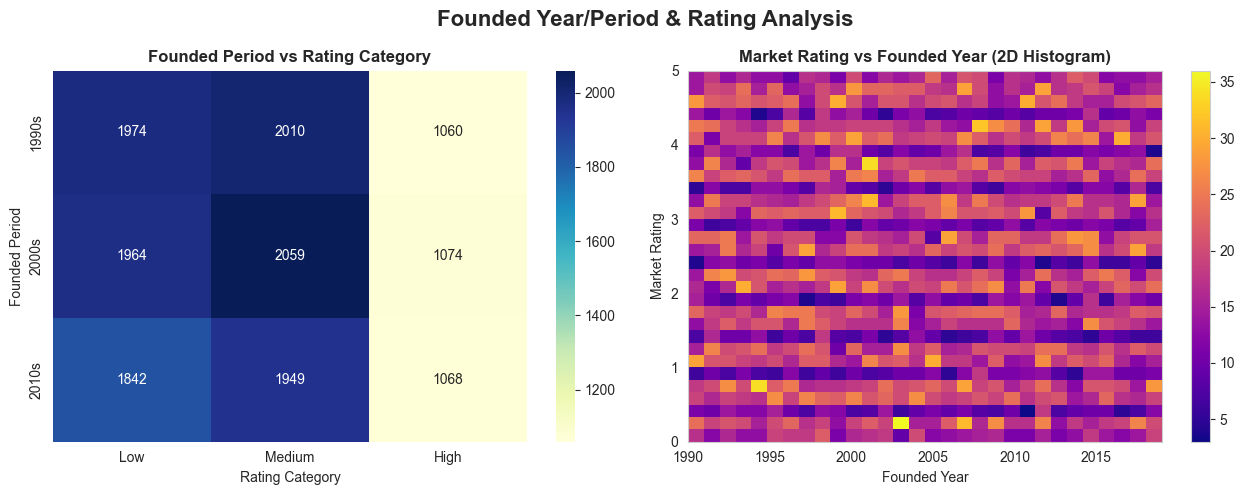

In [69]:
ct_period_rating = pd.crosstab(df['founded_period'], df['rating_category'])
display(ct_period_rating)

fig, ax = plt.subplots(1, 2, figsize=(13,5))

# Heatmap
sns.heatmap(ct_period_rating, annot=True, fmt='d', cmap='YlGnBu', ax=ax[0])
ax[0].set_title('Founded Period vs Rating Category', fontweight='bold')
ax[0].set_xlabel('Rating Category')
ax[0].set_ylabel('Founded Period')

# 2D Histogram
hb = ax[1].hist2d(df['founded_year'], df['market_rating'],bins=(30,30), cmap='plasma')
ax[1].set_title('Market Rating vs Founded Year (2D Histogram)', fontweight='bold')
ax[1].set_xlabel('Founded Year')
ax[1].set_ylabel('Market Rating')
fig.colorbar(hb[3], ax=ax[1])

fig.suptitle('Founded Year/Period & Rating Analysis', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


### `Founded Period vs Rating Category`
### `Heatmap`
- Across all decades, the `Medium rating` category leads with counts around `2,000`, showing that most companies maintain balanced market reputations rather than extreme highs or lows.  
- The distribution remains remarkably consistent for all decades, suggesting that founding period has limited influence on market rating — firms across generations tend to converge toward similar rating profiles.  
- The `2010s` shows marginally lower counts across all rating categories, hinting that younger firms may still be building reputation and market credibility.  
- The `High rating` column is significantly smaller  for all decades than Low and Medium, indicating that achieving top market ratings is challenging and likely tied to long‑term brand maturity or operational excellence.  
- The `Low rating` group remains substantial (~1,800–1,970 firms), implying that a notable portion of firms struggle to differentiate or maintain consistent market performance.

### `2D Histogram`
- The histogram shows a broad, even spread of firms across founding years and market ratings, confirming that company age doesn’t strongly dictate rating level.  
- The highest concentration lies between ratings `2–4` and years `1995–2015`, reinforcing the mid‑range dominance seen in the heatmap.  
- Few firms occupy the lowest (0–1) or highest (4.5–5) rating bins, suggesting that both underperformers and elite performers are rare.  
- No visible upward or downward trend over time — ratings remain stable across decades, reflecting a mature, competitive market environment.

### The data reveals a mature, reputation‑balanced market where most firms cluster around medium ratings regardless of founding era. Newer firms can achieve comparable ratings to older ones, provided they focus on operational consistency and customer trust. The scarcity of high‑rated firms highlights an opportunity for brand differentiation and quality enhancement— firms that invest in innovation, customer experience, and transparency can break into the elite segment. Conversely, the persistence of low ratings suggests a need for market education and performance improvement among lagging firms. Overall, the pattern underscores market equilibrium— reputation growth is gradual, and sustained excellence, not age, drives higher ratings.

## <mark>8. Customer Count </mark>

### <mark>Customer count vs Market Rating</mark>

rating_category,Low,Medium,High
customer_category,,,
0–20K,1105,1212,598
20K–40K,1182,1173,649
40K–60K,1135,1191,704
60K–80K,1149,1266,609
80K–120K,1209,1176,642


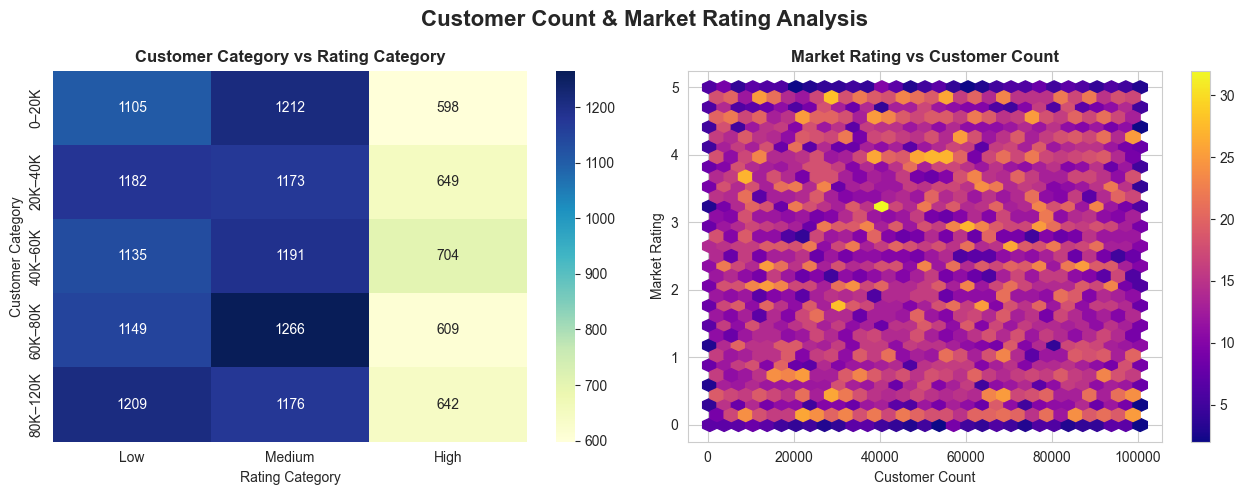

In [70]:
ct_customer_rating = pd.crosstab(df['customer_category'], df['rating_category'])
display(ct_customer_rating)
fig, ax = plt.subplots(1, 2, figsize=(13,5))

# Heatmap
sns.heatmap(ct_customer_rating, annot=True, fmt='d', cmap='YlGnBu', ax=ax[0])
ax[0].set_title('Customer Category vs Rating Category', fontweight='bold')
ax[0].set_xlabel('Rating Category')
ax[0].set_ylabel('Customer Category')

# Hexbin: Customer Count vs Market Rating
hb = ax[1].hexbin(df['customer_count'], df['market_rating'],gridsize=30, cmap='plasma', mincnt=1)

ax[1].set_title('Market Rating vs Customer Count', fontweight='bold')
ax[1].set_xlabel('Customer Count')
ax[1].set_ylabel('Market Rating')

fig.colorbar(hb, ax=ax[1])

fig.suptitle('Customer Count & Market Rating Analysis',fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

### `Customer Category vs Rating Category`
### `Heagtmap`
- Across all customer categories, the `Medium` rating group consistently leads, showing that most companies maintain balanced market reputations regardless of customer scale.  
- The `Low` rating segment mirrors the Medium group closely, suggesting that customer count alone doesn’t guarantee better ratings — operational quality and brand perception likely play stronger roles.  
- The `High` rating column is significantly smaller, indicating that achieving top market ratings is challenging even for firms with large customer bases.  
- The 60K–80K customer category with `Medium` ratings (1,266) represents the most balanced performance — firms here combine scale with moderate reputation, likely reflecting mature, well‑optimized operations.  
- The overall consistency across customer tiers implies that market rating is not strongly correlated with customer volume, reinforcing the idea of a competitive equilibrium.

### `Hexbin`
- The hexbin shows a broad, uniform spread across customer counts and ratings, confirming that rating levels are independent of customer scale.  
- The highest concentration lies between ratings `2–4` and customer counts `20K–80K,` reinforcing the mid‑range dominance seen in the heatmap.  
- Few firms occupy the lowest (rating <1) or highest (rating >4.5) bins, suggesting that both underperformers and elite performers are rare.  
- The absence of strong vertical or horizontal clustering indicates that firms maintain similar rating structures across different customer volumes — a hallmark of market maturity.

### The data reveals a balanced, reputation‑stable market where most firms sustain moderate ratings across varying customer bases. Firms with smaller bases perform comparably to those with larger ones, emphasizing the importance of service quality, customer experience, and brand differentiation. The scarcity of high‑rated firms highlights an opportunity for strategic improvement in customer engagement and perception management. Firms in the `60K–80K` customer range appear to represent the optimal balance between reach and reputation — a benchmark for scaling strategies.

In [71]:
df.head()

,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,rating_category,employee_size,revenue_category,profit_category,founded_period,customer_category
0,Finance,India,535,539.38,40.42,2010,81191,0.7,Low,500–1000,500–750,40–50%,2010s,80K–120K
1,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,Medium,3500–6000,750–1000,30–40%,2010s,80K–120K
2,Retail,Canada,2779,257.11,23.68,1996,27532,2.9,Medium,2000–3500,250–500,20–30%,1990s,20K–40K
3,Manufacturing,USA,835,309.14,31.31,1993,90815,0.9,Low,500–1000,250–500,30–40%,1990s,80K–120K
4,Healthcare,India,4490,988.68,43.65,1996,850,0.5,Low,3500–6000,750–1000,40–50%,1990s,0–20K


# <mark> Multivariate Analysis </mark>

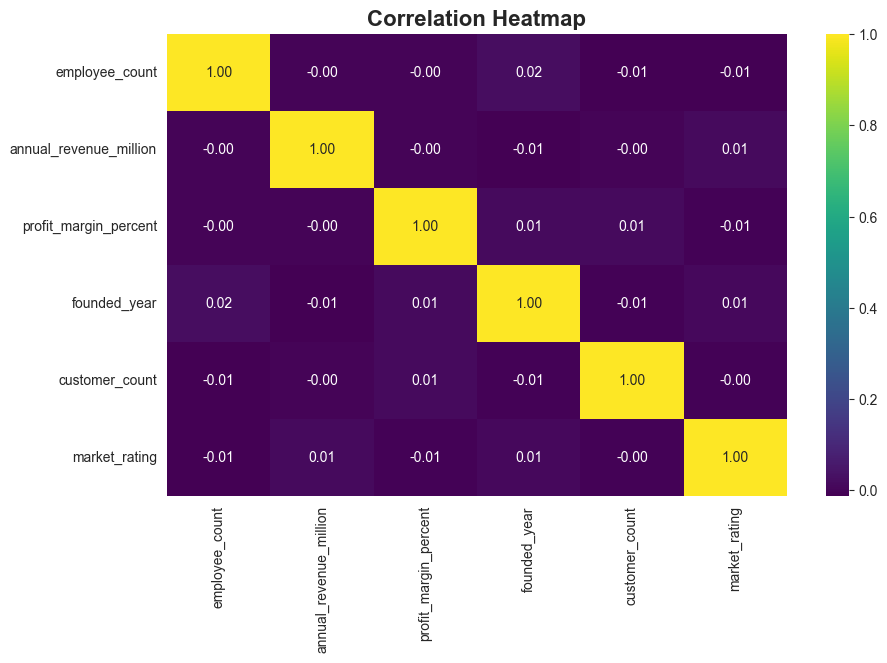

In [72]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='viridis',
    fmt='.2f'
)

plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.show()

### The heatmap shows that all correlation are extremely close to zero(ranging approximately -0.01 to 0.02). This indicates there is vertually no linear relationship between any pair of numerical variable in the datset. The absence of strong correlations suggest minimal multicollinearityamong features.

# <mark>Machine Learning </mark>

In [85]:
ml_df=df.copy()

In [86]:
ml_df.drop(columns=['rating_category','employee_size','revenue_category','profit_category', 'founded_period', 'customer_category'], inplace=True)

In [87]:
print(ml_df.columns.tolist())
print(ml_df.shape)

['industry', 'country', 'employee_count', 'annual_revenue_million', 'profit_margin_percent', 'founded_year', 'customer_count', 'market_rating']
(15000, 8)


In [91]:
X=ml_df.drop(columns=['annual_revenue_million'])
y=ml_df['annual_revenue_million']

### `annual_revenue_million` is a target variable. Seperate this column with other dataset.

### <mark>Encoding Categorical Variable</mark>

In [ ]:
X = pd.get_dummies(X,columns=['industry', 'country'],drop_first=True)

In [94]:
print(X.shape)
print(X.head())

(15000, 12)
   employee_count  profit_margin_percent  founded_year  customer_count  \
0             535                  40.42          2010           81191   
1            3806                  39.55          2010           92162   
2            2779                  23.68          1996           27532   
3             835                  31.31          1993           90815   
4            4490                  43.65          1996             850   

   market_rating  industry_Healthcare  industry_Manufacturing  \
0            0.7                False                   False   
1            3.4                False                   False   
2            2.9                False                   False   
3            0.9                False                    True   
4            0.5                 True                   False   

   industry_Retail  industry_Technology  country_Germany  country_India  \
0            False                False            False           True   
1 

### <mark>Split into Train Test Sets</mark>

In [95]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2,random_state=42)

### <mark>Scaling</mark>

In [96]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


### <mark> Linear Regression</mark>

In [107]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


lr = LinearRegression()
lr.fit(X_train, y_train)

lr.score(X_test, y_test)*100, lr.score(X_train, y_train)*100

(-0.13028637157079803, 0.09356872651994363)

### <mark>Lasso Regression</mark>

In [108]:
ls = Lasso(alpha=10)
ls.fit(X_train, y_train)
ls.score(X_test, y_test)*100, ls.score(X_train, y_train)*100

(-0.054443462946429655, 0.0)

### <mark>Ridge Regression </mark>

In [110]:
rd = Ridge(alpha=0.05)
rd.fit(X_train, y_train)
rd.score(X_test, y_test)*100, rd.score(X_train, y_train)*100

(-0.1302853488092559, 0.09356872651646864)

### <mark>Elastic Net</mark>

In [111]:
en = ElasticNet(alpha=10)
en.fit(X_train, y_train)
en.score(X_test, y_test)*100, en.score(X_train, y_train)*100

(-0.054443462946429655, 0.0)

### <mark>Decision Tree</mark>

In [113]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=10)
dt.fit(X_train, y_train)
dt.score(X_test, y_test)*100, dt.score(X_train, y_train)*100

(-6.023875173628279, 5.236541747058632)

### <mark> Random Forest</mark>

In [119]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf.score(X_test, y_test)*100, rf.score(X_train, y_train)*100

(-3.4886464717039267, 85.74028766762609)

### <mark>SVR</mark>

In [124]:
from sklearn.svm import SVR

sv = SVR()
sv.fit(X_train, y_train)
sv.score(X_test, y_test)*100, sv.score(X_train, y_train)*100

(-0.23226215280636175, 0.3004241286834963)

### <mark>KNN</mark>

In [126]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor()
knn.fit(X_train, y_train)
knn.score(X_test, y_test)*100, knn.score(X_train, y_train)*100

(-17.83073194416307, 19.473923066870334)

### Multiple regression models including Linear Regression, Ridge/Lasso, Decision Tree, Random Forest, SVR, and KNN were evaluated. All models produced negative test R² scores, indicating poor predictive performance on unseen data. 

### Among the evaluated models, Lasso Regression and Elastic Net achieved the highest test R² score (-0.0544), making them the best-performing models relative to the alternatives. However, their predictive performance remained weak, suggesting that the available features did not provide sufficient explanatory power for predicting annual revenue.
